In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
telco_details = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
telco_details

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
telco_details.shape

(7043, 21)

In [4]:
telco_details.duplicated().any()

np.False_

## problem statement here is:

- churning is one of the reasons that can affect the company's growth
- it help us to make a better decision on customer service

### As we don't need customer ID, I just have to delete the feature

In [3]:
telco_details_new = telco_details.drop(columns = "customerID")
telco_details_new

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
telco_details_new.shape

(7043, 20)

In [5]:
telco_details_new.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
telco_details_new["TotalCharges"].dtypes

dtype('O')

In [7]:
telco_details_new["TotalCharges"] = pd.to_numeric(telco_details_new["TotalCharges"],errors = "coerce")
telco_details_new

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [8]:
telco_details_new["TotalCharges"].dtypes

dtype('float64')

In [9]:
telco_details_new["TotalCharges"].isna().sum()

np.int64(11)

In [10]:
telco_details_new = telco_details_new.dropna(subset = ["TotalCharges"]).copy()
telco_details_new

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


### why is the above step for?

- i converted the monthlycharges from object to float by coerced. so this creates NaN values inside that column by removing the invalid things which make that column string.

- but when it comes to statistical test the p_value will also be NaN, if any one of the data in the feature have NaN. so we dropped the rows in monthly charges which contains NaN.

In [11]:
telco_details_new["TotalCharges"].isna().sum()

np.int64(0)

In [12]:
telco_details_new.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Univariate Analysis

distribution of gender


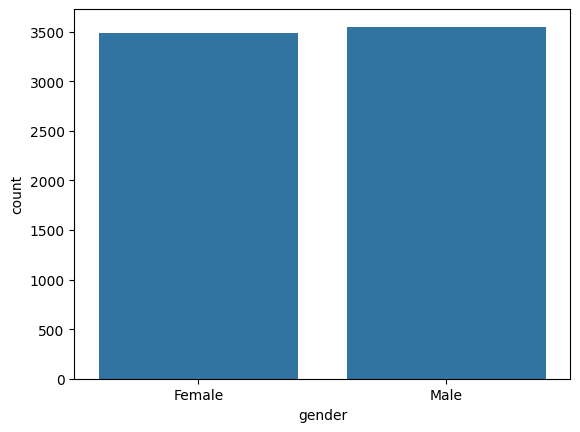

distribution of SeniorCitizen


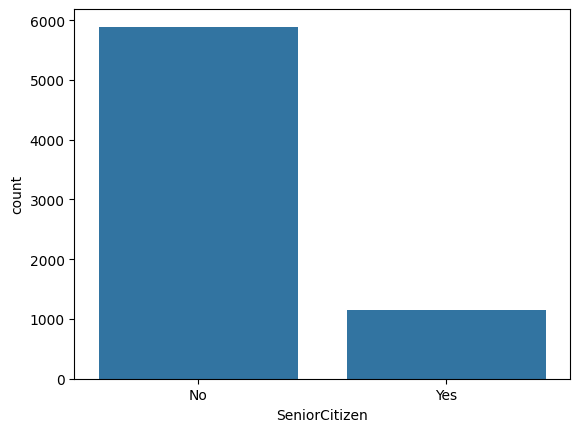

distribution of Partner


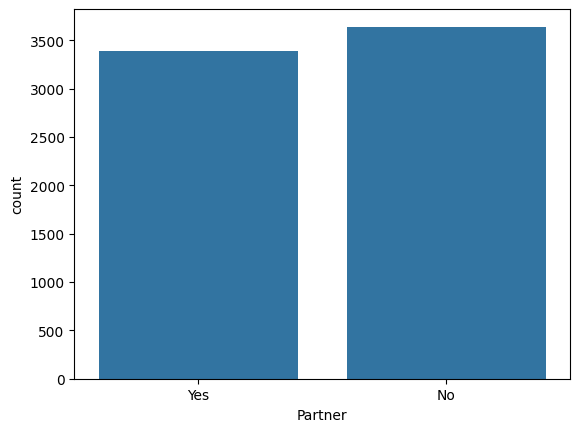

distribution of Dependents


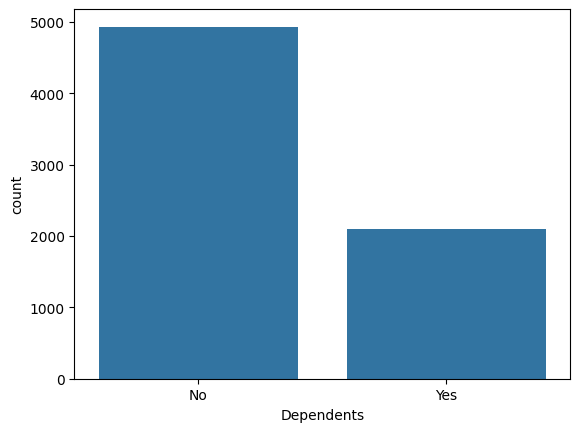

distribution of PhoneService


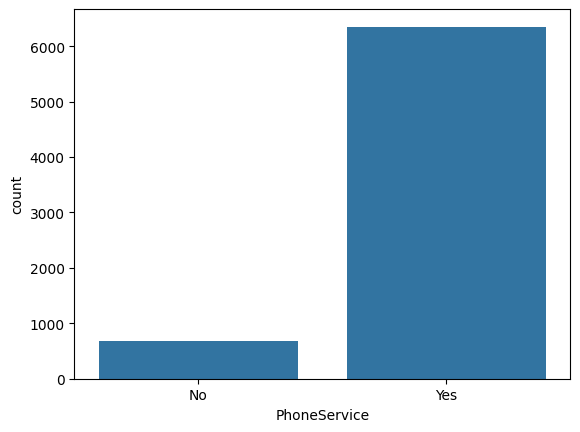

distribution of MultipleLines


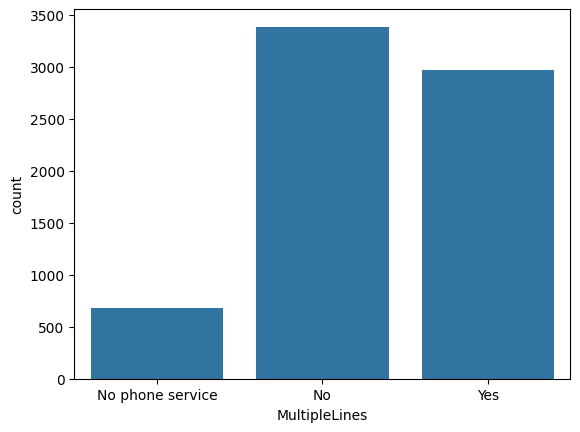

distribution of InternetService


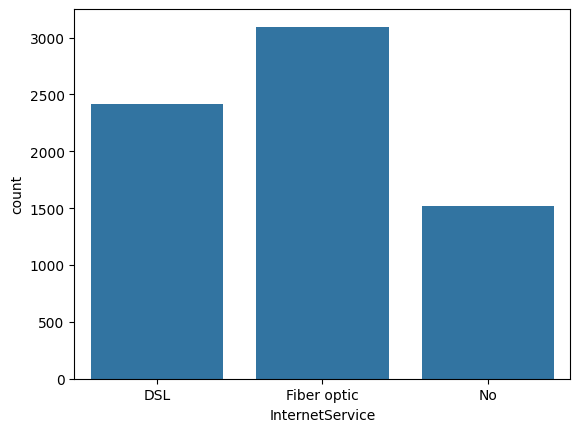

distribution of OnlineSecurity


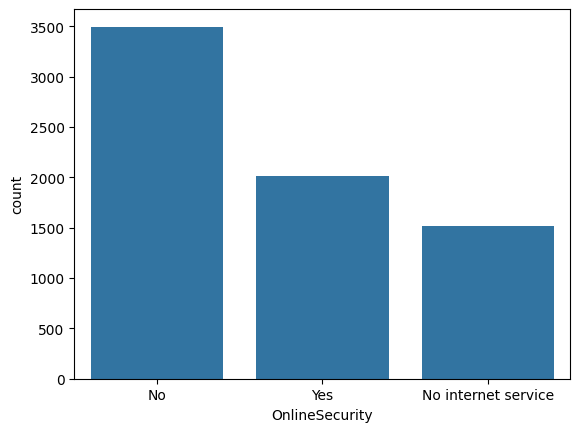

distribution of OnlineBackup


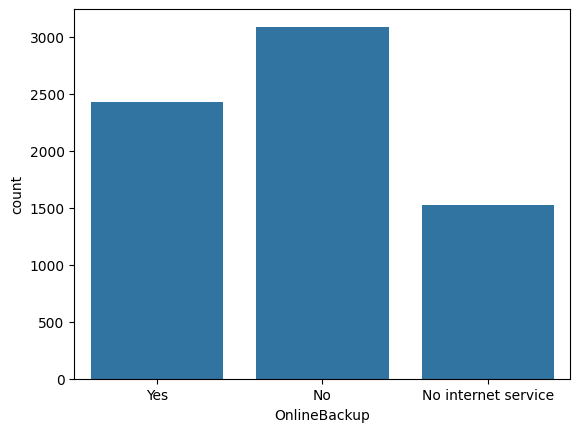

distribution of DeviceProtection


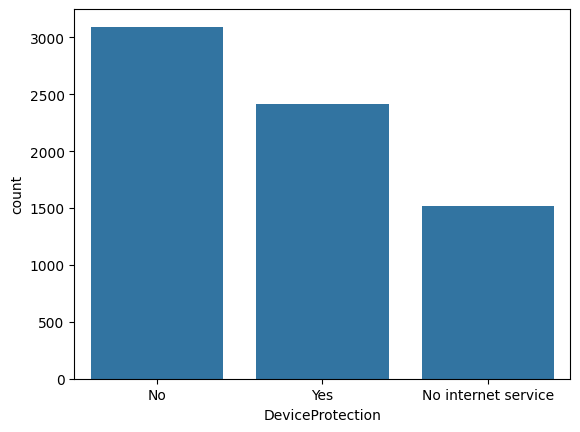

distribution of TechSupport


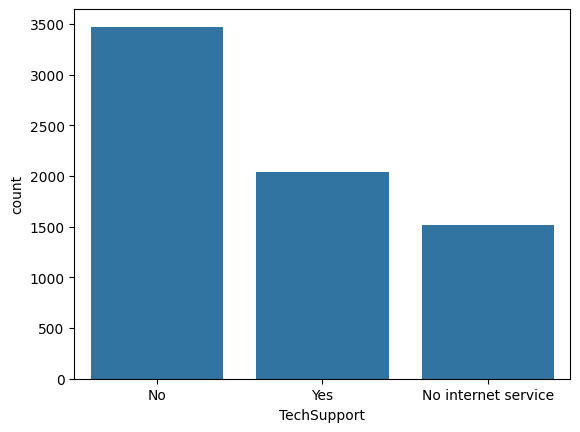

distribution of StreamingTV


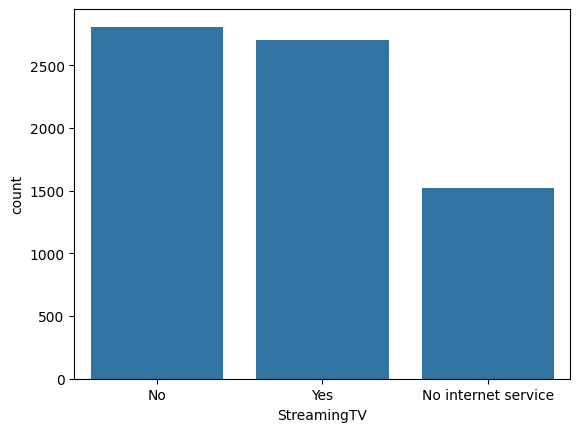

distribution of StreamingMovies


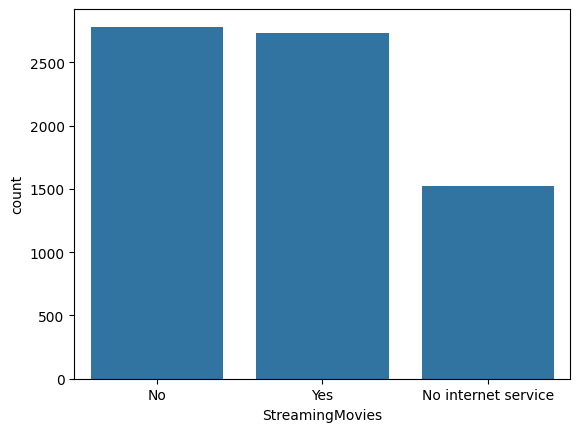

distribution of Contract


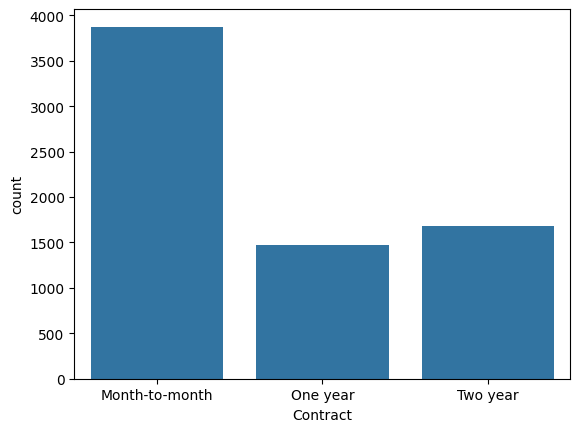

distribution of PaperlessBilling


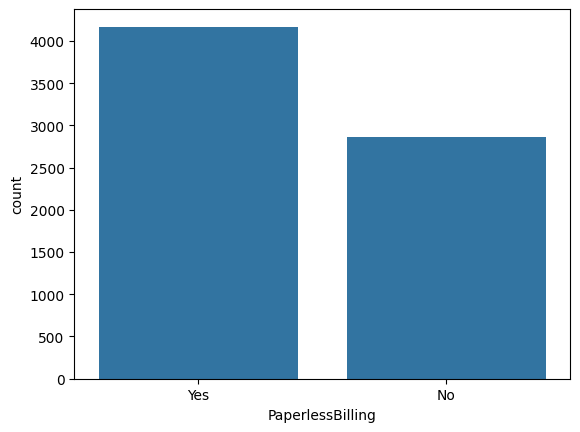

distribution of PaymentMethod


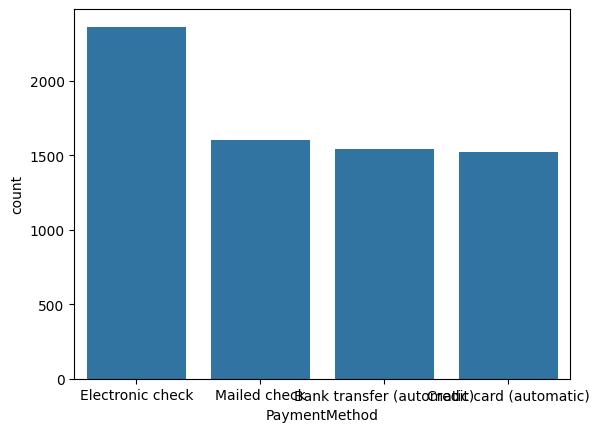

In [13]:
telco_details_new["SeniorCitizen"] = telco_details_new["SeniorCitizen"].map({1: "Yes", 0: "No"})

categorical_col3 = telco_details_new.select_dtypes(include = "object").columns
categorical_col3 = categorical_col3.drop("Churn")

for i, predictor in enumerate(categorical_col3):
    
        print(f"distribution of {predictor}")
        plt.figure(i)
        sns.countplot(data= telco_details_new, x= predictor)
        plt.show()




In [14]:
categorical_col3

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [15]:
telco_details_new

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


## OBSERVATIONS

- The number of independent people is more than the people who are dependent
  
- monthly plan users are high than the yearly plan users

### boxplot for numerical data do!

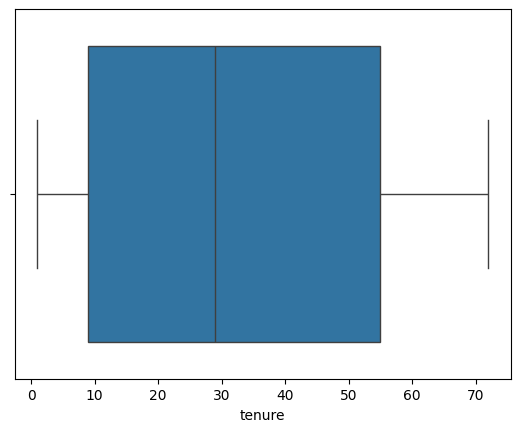

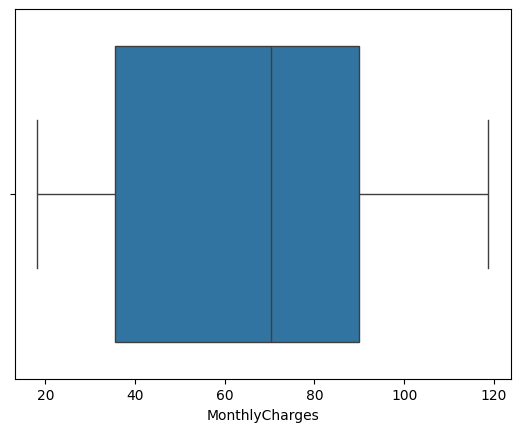

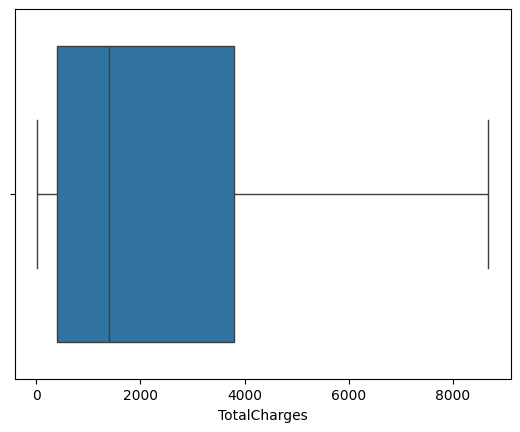

In [16]:

numerical_col1 = telco_details_new.select_dtypes(include = "number").columns

for i, predictor in enumerate(numerical_col1):
    plt.figure(i)
    sns.boxplot(data = telco_details_new, x= predictor)
    plt.show()

## OBSERVATIONS

TENURE:
- Tenure is approximately normally distributed, showing customers across different service durations
  
MONTHLY CHARGES:
- Monthly charges are rightly-skewed, indicating most customers falls under moderate billing plans

TOTAL CHARGES:
- Total charges are leftly-skewed, indicating many customers have accumulated higher payments overtime 

## Bivariate Analysis

### Catagorical VS Target - Countplot

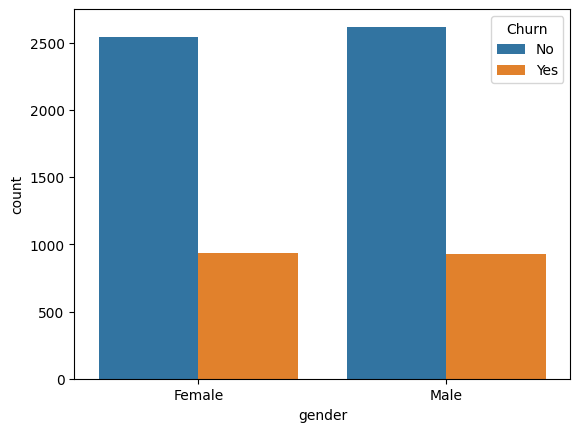

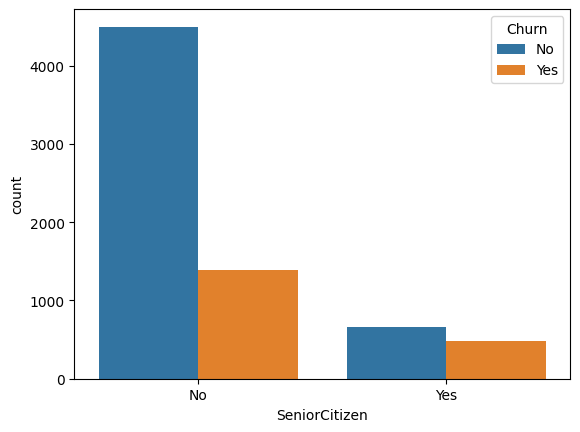

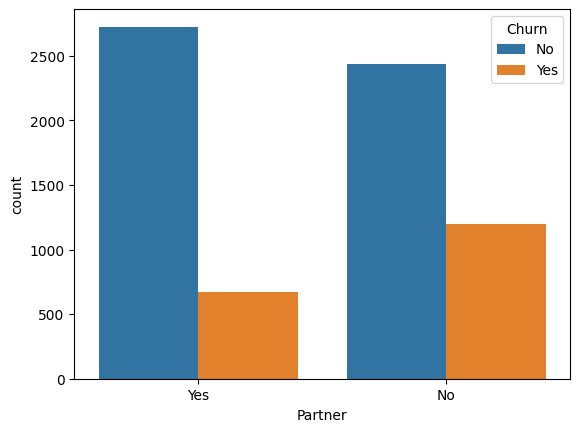

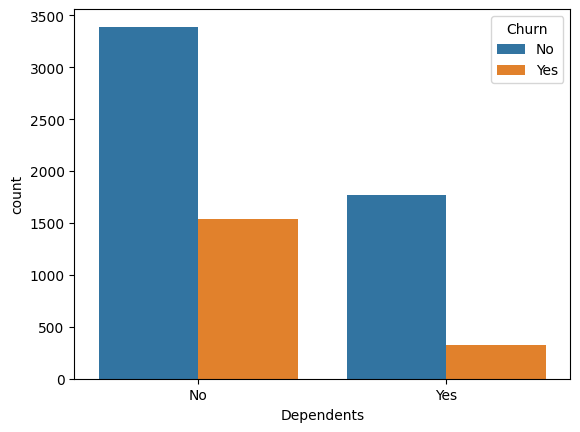

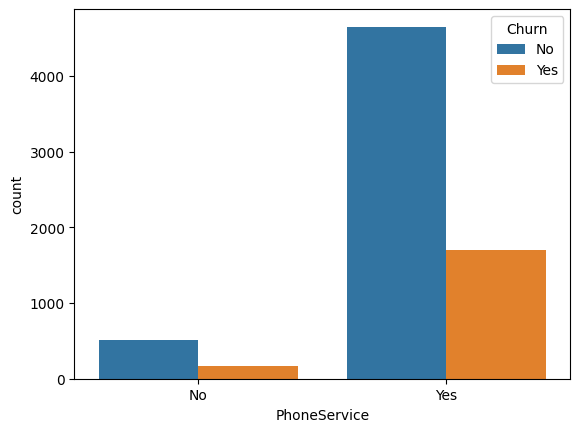

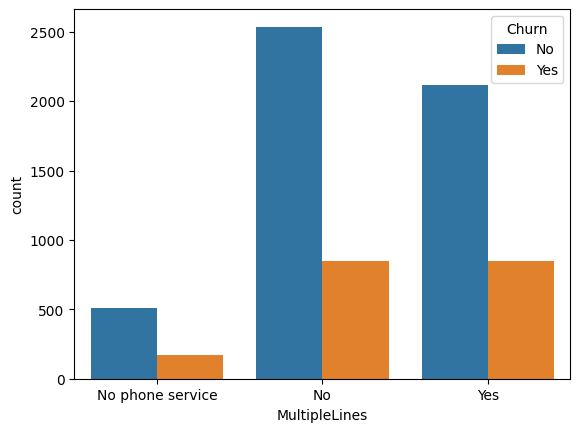

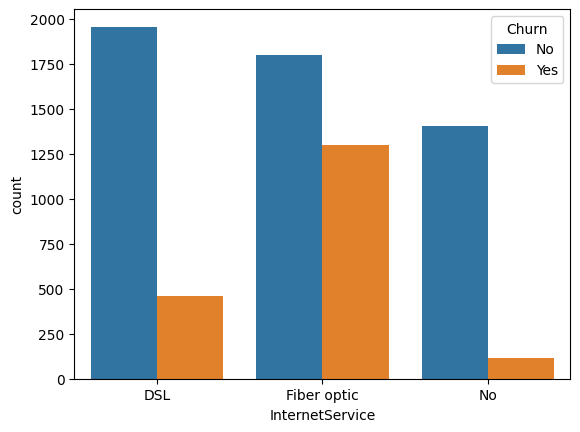

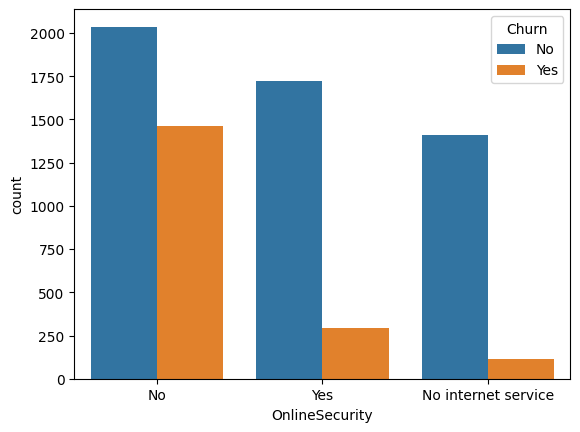

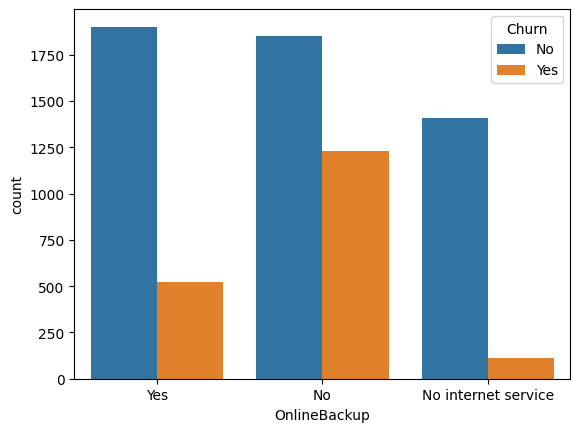

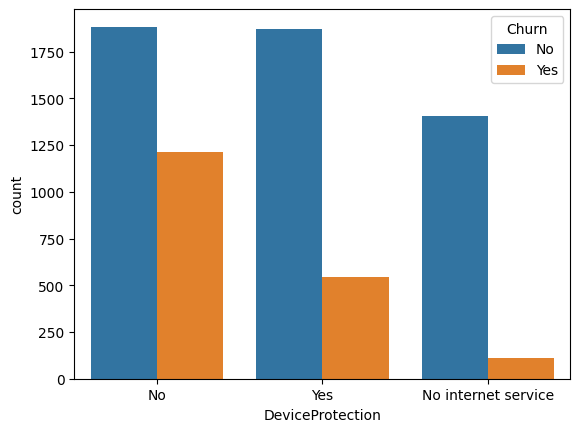

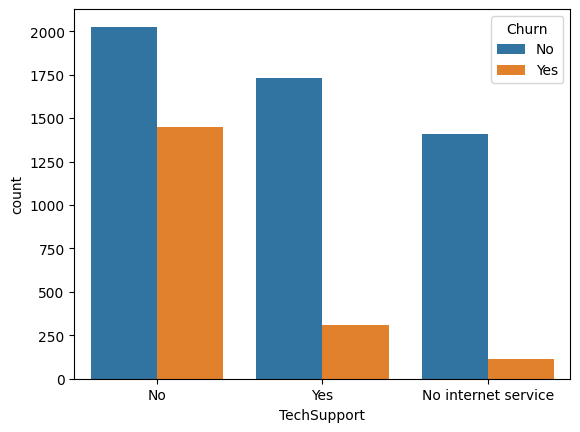

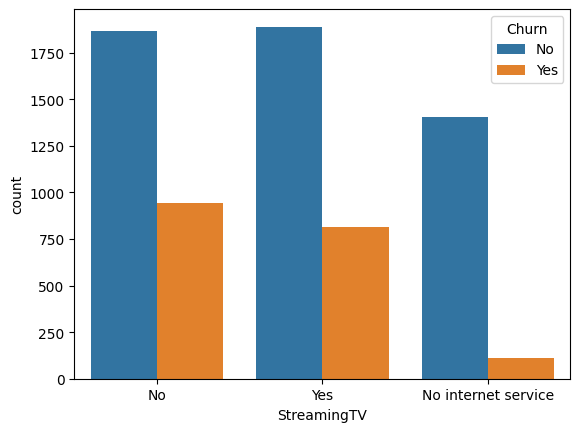

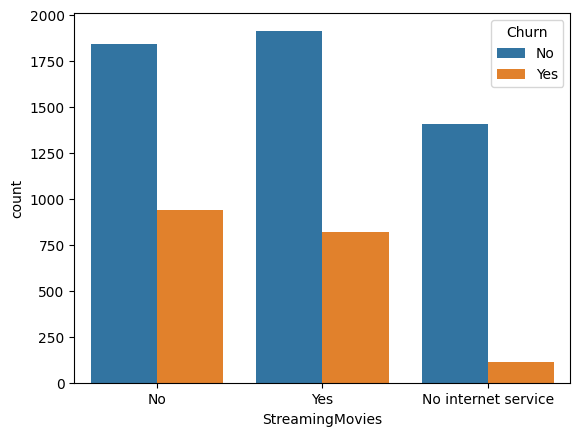

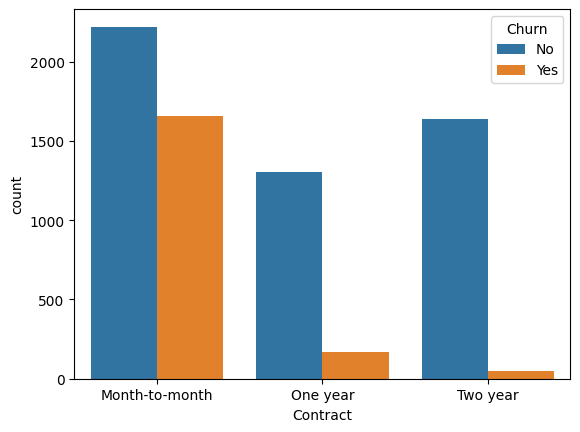

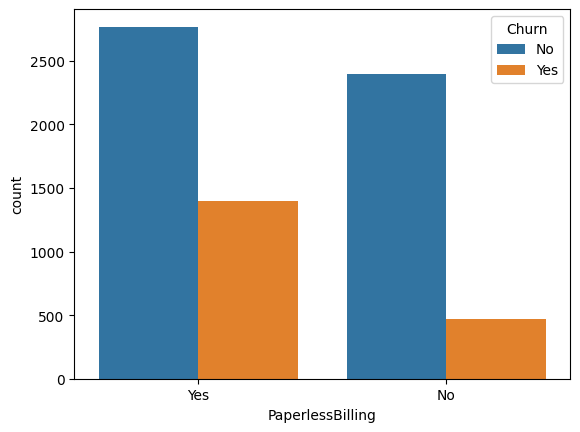

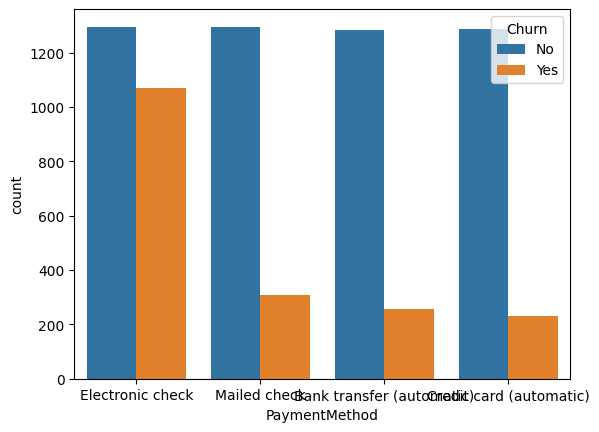

In [17]:
for i, predictor in enumerate(telco_details_new.drop(columns = ["tenure","MonthlyCharges","TotalCharges","Churn"])):
    plt.figure(i)
    sns.countplot(data = telco_details_new, x = predictor, hue = "Churn")
    plt.show()

In [18]:
categorical_cols = telco_details_new.select_dtypes(include = "object").columns
categorical_cols

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

#### as i select only the object, the output inlcudes TotalCharges also. so I've to check whether it has any string with it

In [19]:
categorical_cols2 = telco_details_new.select_dtypes(include = "object").columns
categorical_cols2

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

## churn percentage for each features

In [20]:
categorical_cols2 = telco_details_new.select_dtypes(include = "object").columns
categorical_cols2 = categorical_cols2.drop("Churn")

for predictor in categorical_cols2:
    
    print(f"churn percentage for:{predictor}")
    
    display(
        pd.crosstab(telco_details_new[predictor],telco_details_new["Churn"],normalize = "index")*100
    )


churn percentage for:gender


Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


churn percentage for:SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.349745,23.650255
Yes,58.318739,41.681261


churn percentage for:Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


churn percentage for:PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.624302,16.375698
Yes,66.410749,33.589251


churn percentage for:PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


## OBSERVATIONS:

- The churn percentage analysis across categorical features revealed several strong behavioral patterns associated with customer churn.

**partners and dependents:**
- Customers without partners and customers without dependents showed relatively higher churn rates, suggesting that customers with fewer household commitments may be more likely to discontinue services.

**Internet service, Online Security, Online Backup, Device Protection and Tech Support:**
- Among service-related features, customers using Fiber Optic internet service showed significantly higher churn compared to DSL and no internet users. Additionally, customers who did not subscribe to value-added services such as Online Security, Online Backup, Device Protection, and Tech Support had noticeably higher churn rates, indicating that customers with fewer service attachments are more likely to leave.

**Phone Service and Multiple Lines:**
- Phone Service and Multiple Lines did not show major differences in churn behavior, suggesting that these features may have weaker predictive influence.

**Streaming TV and Streaming Movies:**
- For entertainment services such as Streaming TV and Streaming Movies, churn differences between users and non-users were minimal, indicating limited direct impact on churn prediction.

**Contract Type:**
- Contract type showed one of the strongest churn signals. Customers with Month-to-Month contracts had substantially higher churn compared to customers with One-Year or Two-Year contracts, suggesting that longer contractual commitment improves retention.

**Paperless Billing and Payment Method:**
- Customers using Paperless Billing also showed higher churn rates, and among payment methods, customers using Electronic Check had the highest churn percentage, making these strong indicators for churn behavior.

**Overall:**
- Overall, customer retention appears to be strongly associated with service commitment, contract duration, and value-added service adoption rather than basic phone services alone. (dependent with the company is indirectly proportion to the churn rate)

## Numeric VS Target

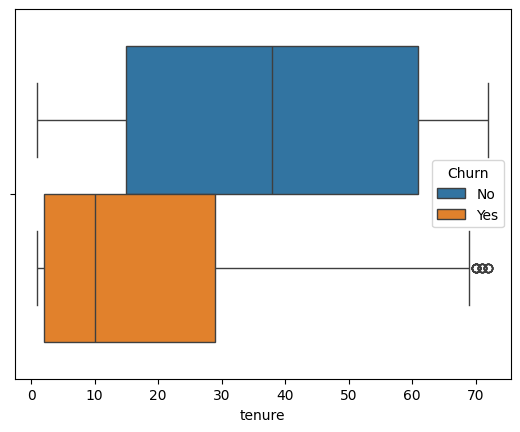

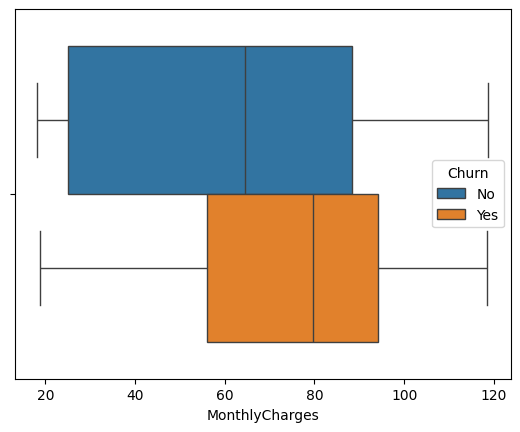

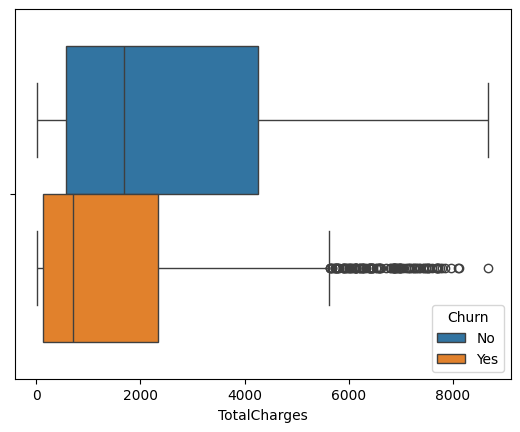

In [21]:
numerical_col = telco_details_new.select_dtypes(include = "number").columns


for i, predictor in enumerate(numerical_col):
    sns.boxplot(data = telco_details_new,x= predictor, hue = "Churn" )
    plt.show()



## OBSERVATIONS:

TENURE:
   - customers who churned generally have lower tenure, suggested they tend to leave earlier compare to the remaining customer

MONTHLY CHARGES:
   - customers who chuned generally have higher monthly charges, suggested they tend to leave after had higher cost

TOTAL CHARGES:
   - customers who churned generally have lower total charges, suggested they tend to leave earlier compare to the customers who remains

   - however some high-value customers also churned, as indicated by outliers in the churned group

### we have to analyse data:

- Target - churn
- hue - gender (in each features)

In [22]:
pd.crosstab(
    telco_details_new["gender"],
    telco_details_new["Churn"]
) * 100

Churn,No,Yes
gender,,
Female,254400,93900
Male,261900,93000


In [23]:
numeric = telco_details_new.select_dtypes("number")

for predictor in numeric:
    display(
        telco_details_new.groupby(['gender', 'Churn']) [predictor].mean()
    )

gender  Churn
Female  No       37.933176
        Yes      17.004260
Male    No       37.374952
        Yes      18.963441
Name: tenure, dtype: float64

gender  Churn
Female  No       61.674941
        Yes      74.812087
Male    No       60.950401
        Yes      74.066989
Name: MonthlyCharges, dtype: float64

gender  Churn
Female  No       2594.054422
        Yes      1440.979499
Male    No       2517.742402
        Yes      1623.491559
Name: TotalCharges, dtype: float64

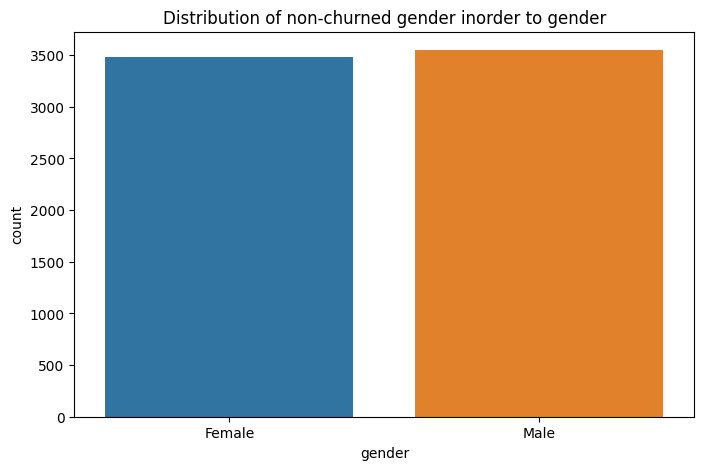

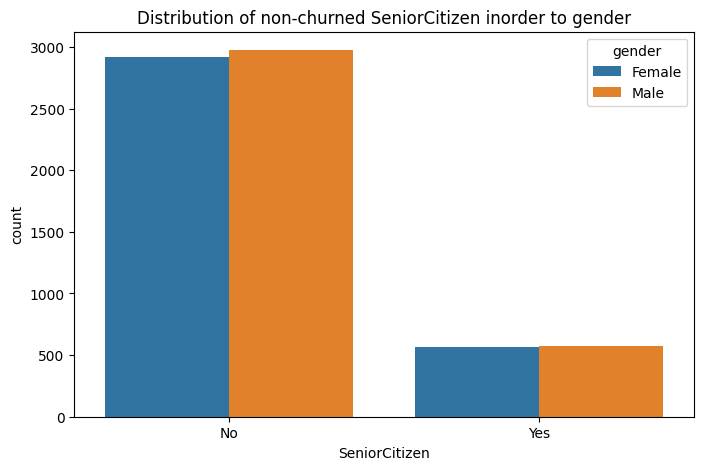

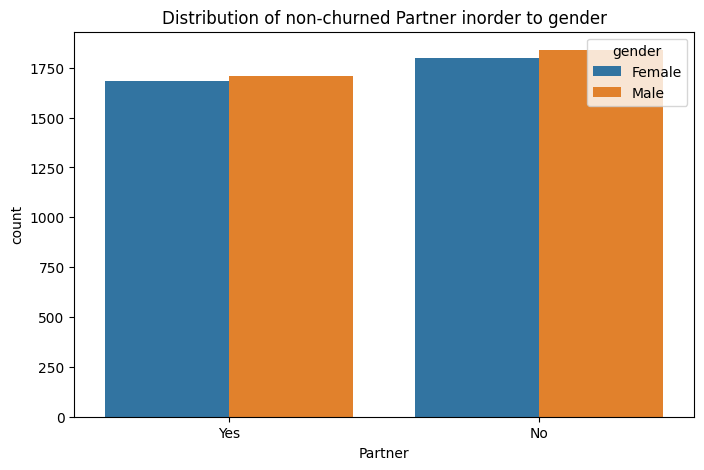

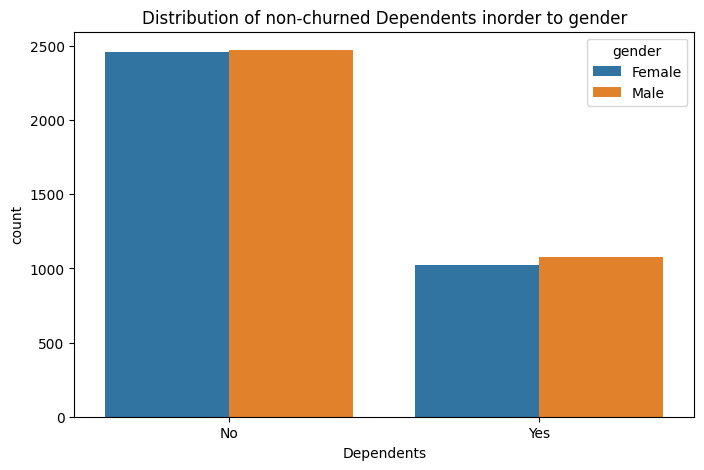

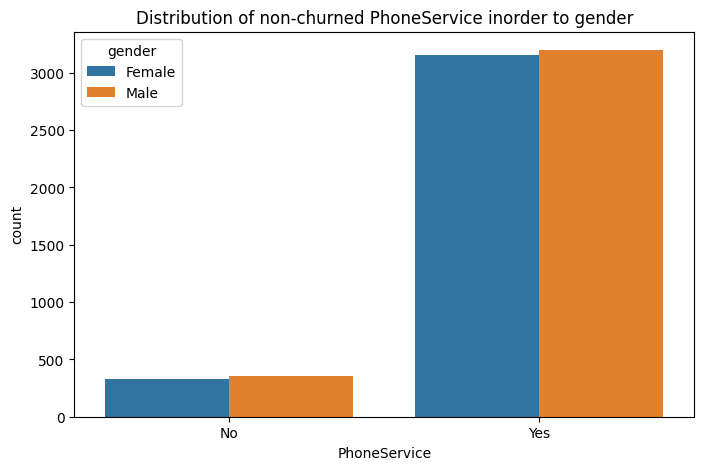

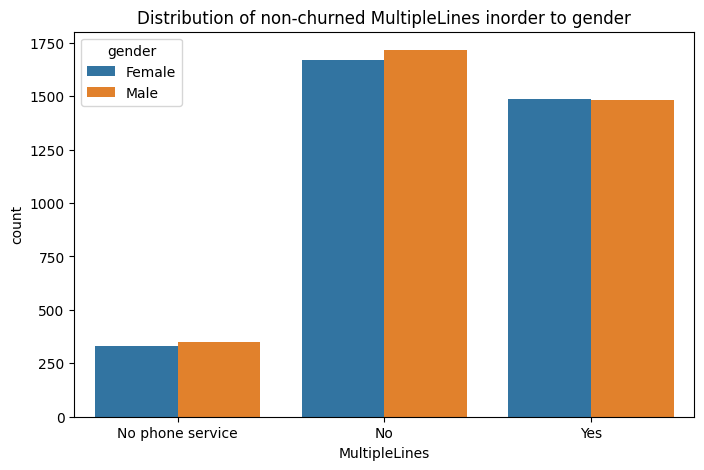

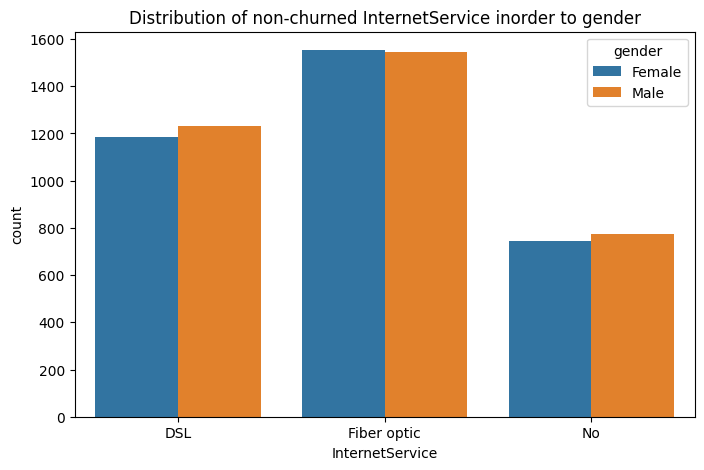

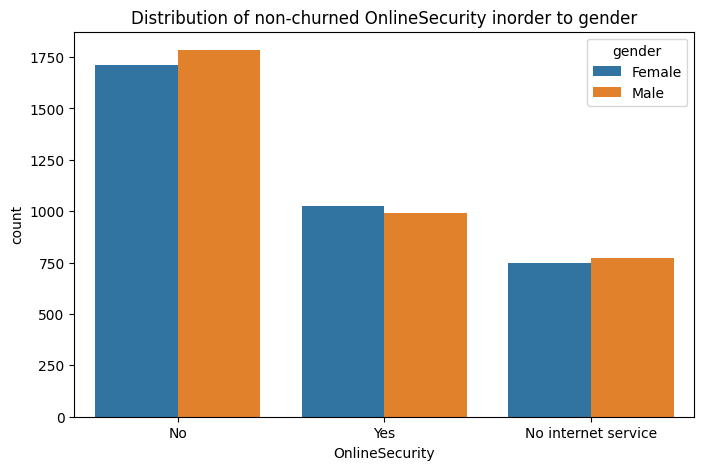

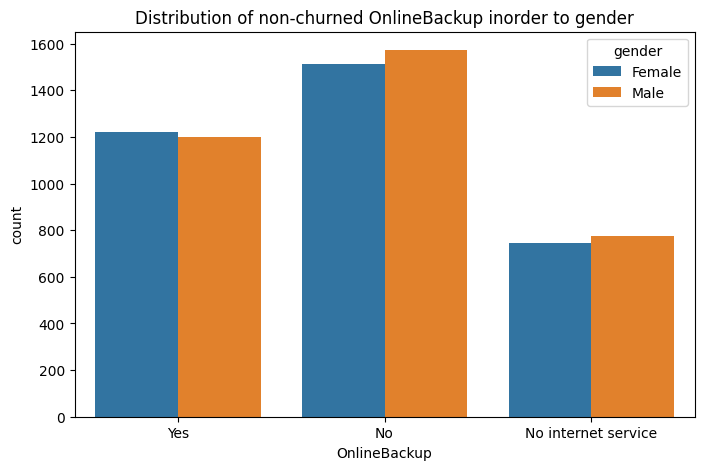

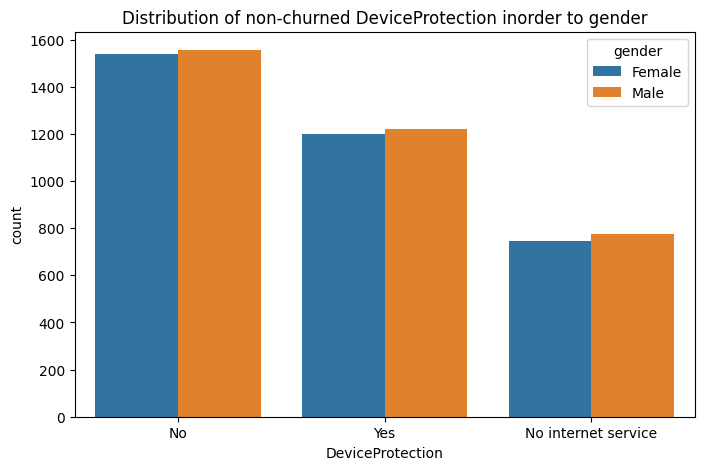

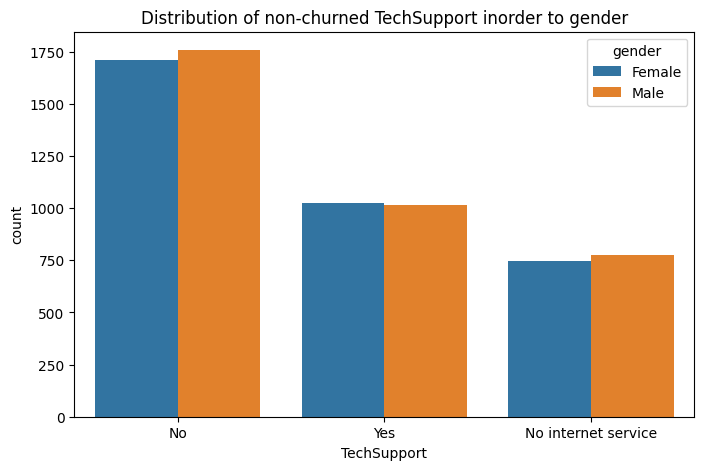

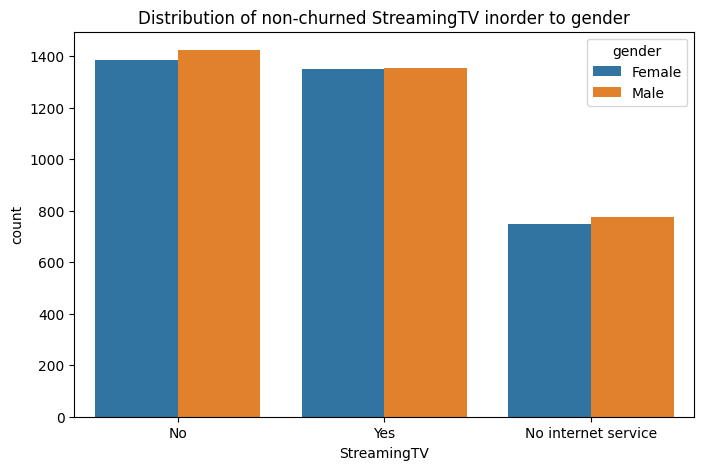

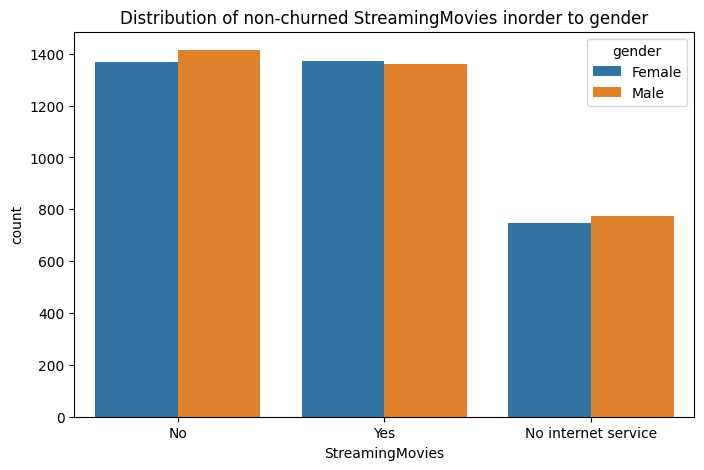

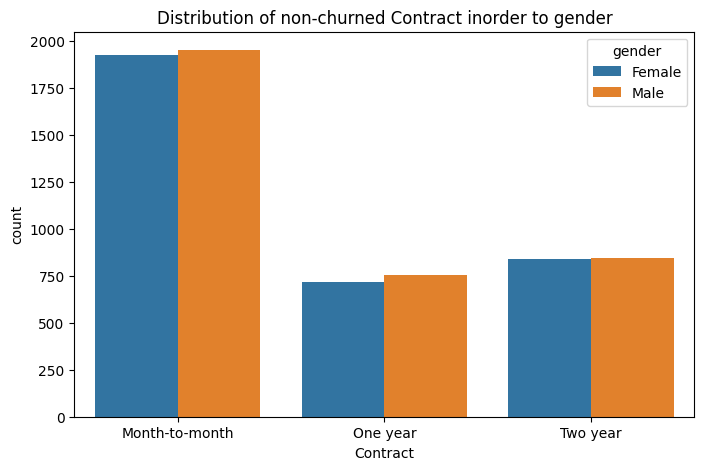

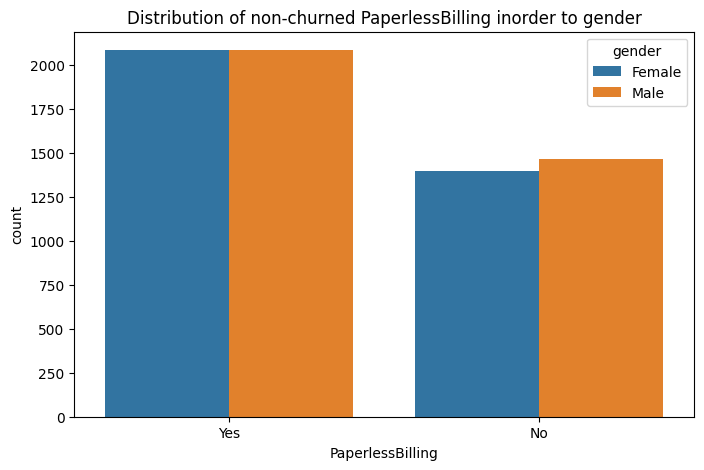

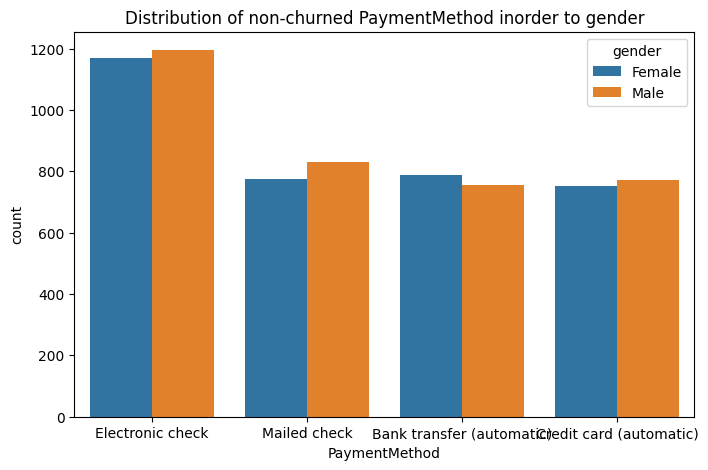

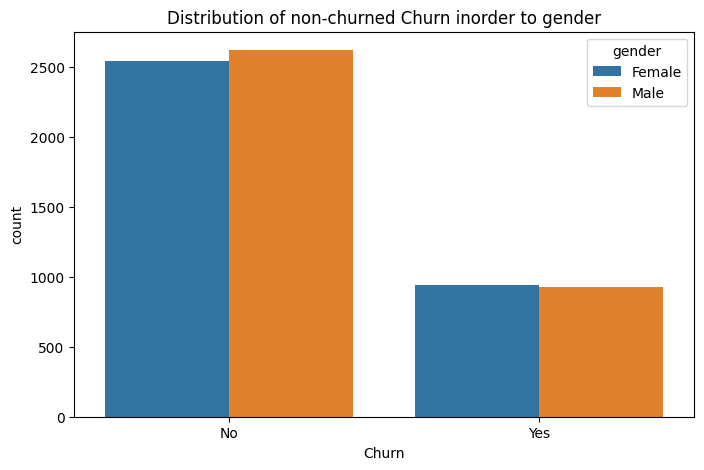

In [24]:
target_1 = telco_details_new[telco_details_new["Churn"]=="No"]
target_2 = telco_details_new[telco_details_new["Churn"]=="Yes"]

categorical_cols4 = telco_details_new.select_dtypes(include = "object").columns

def uniplot(target_1, predictor, hue ="gender"):
    plt.figure(figsize = (8,5))
    plt.title(f"Distribution of non-churned {predictor} inorder to gender")
    sns.countplot(data = telco_details_new, x = predictor, hue = "gender")
    plt.show()

for predictor in categorical_cols4:
    uniplot(target_1, predictor, hue = "gender")

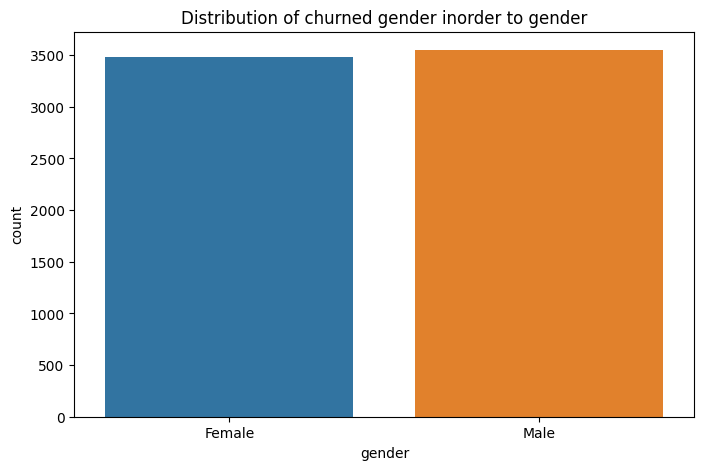

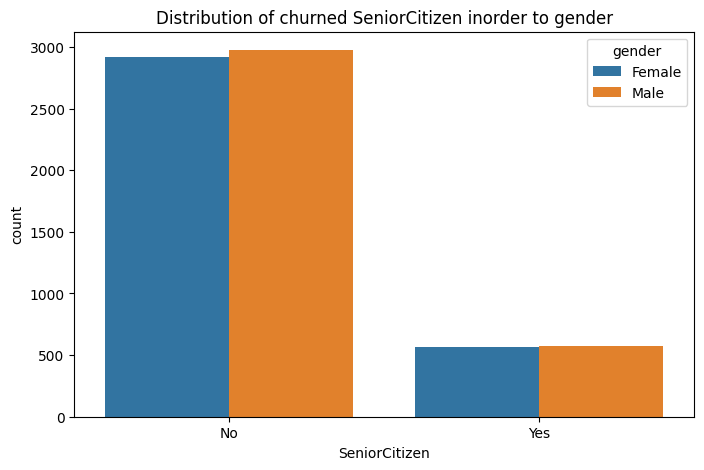

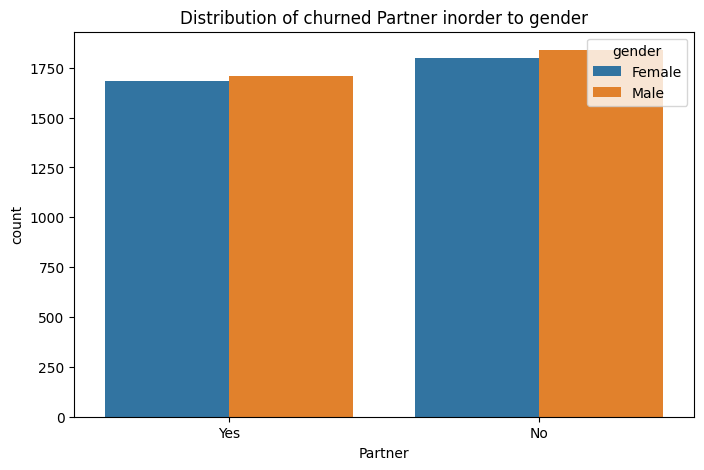

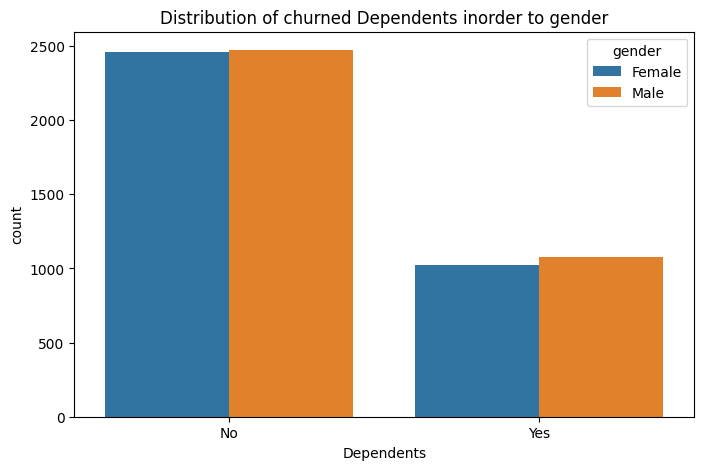

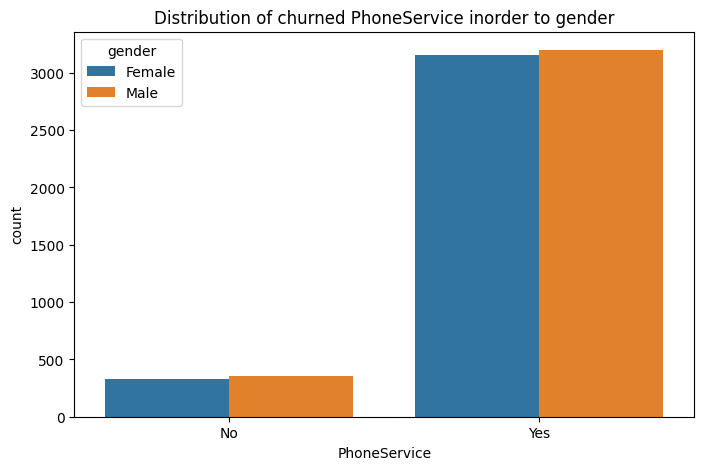

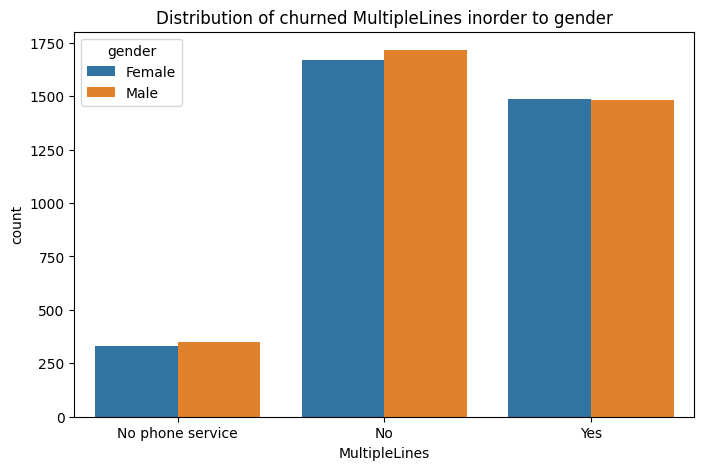

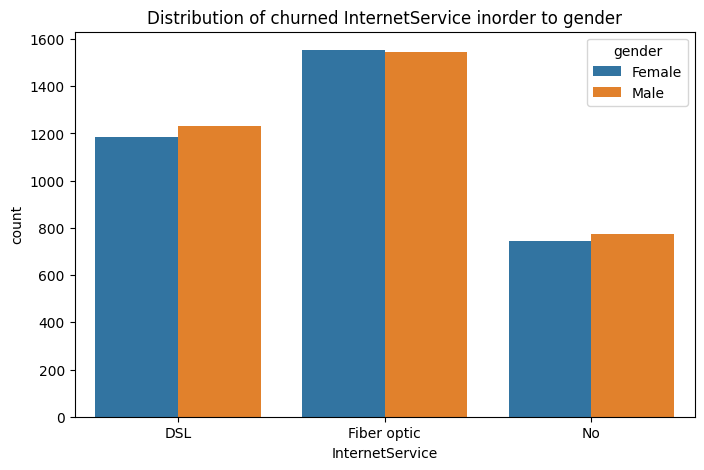

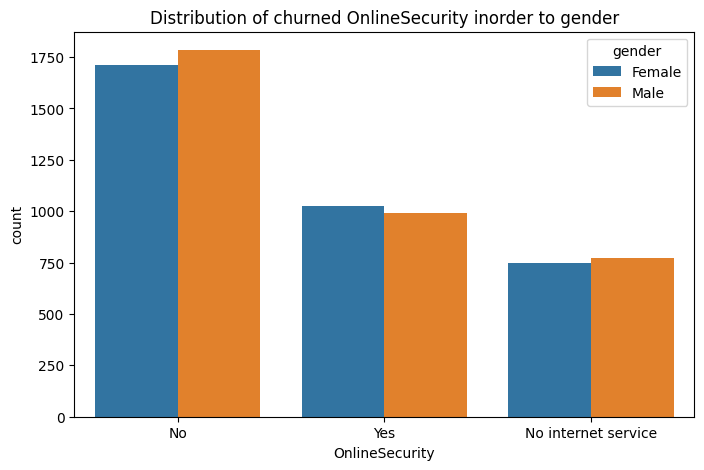

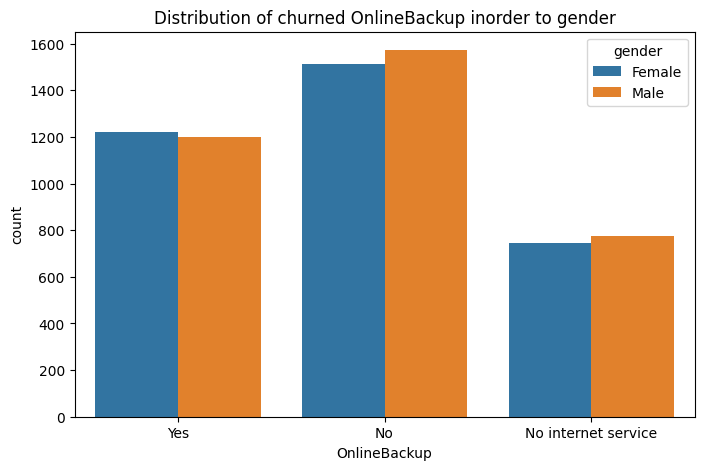

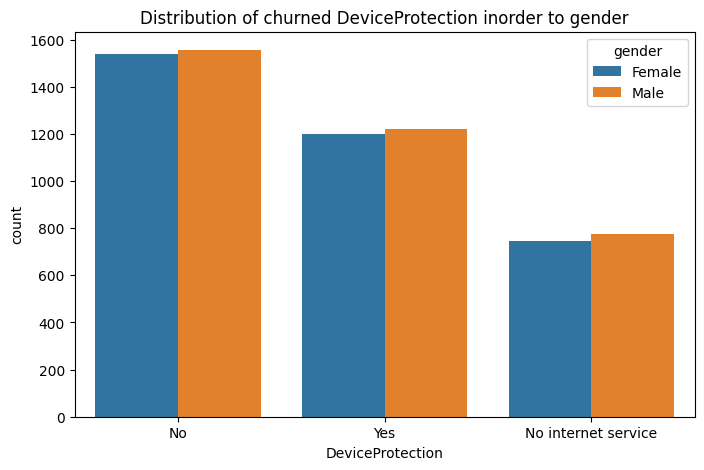

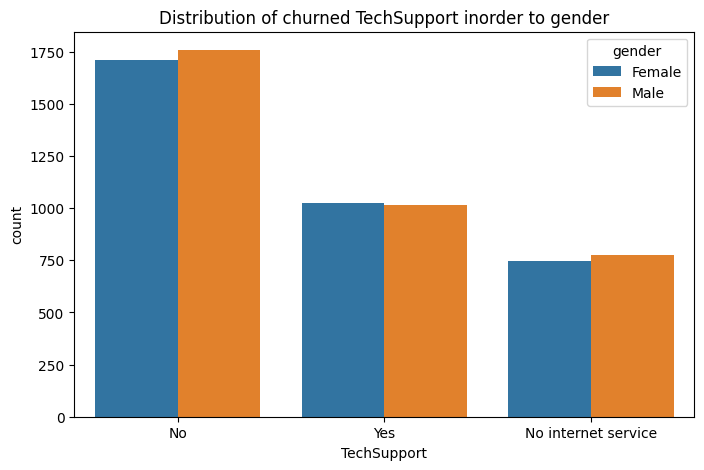

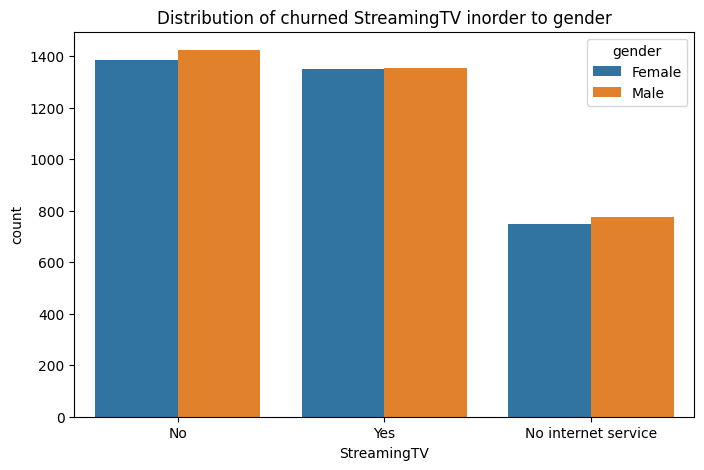

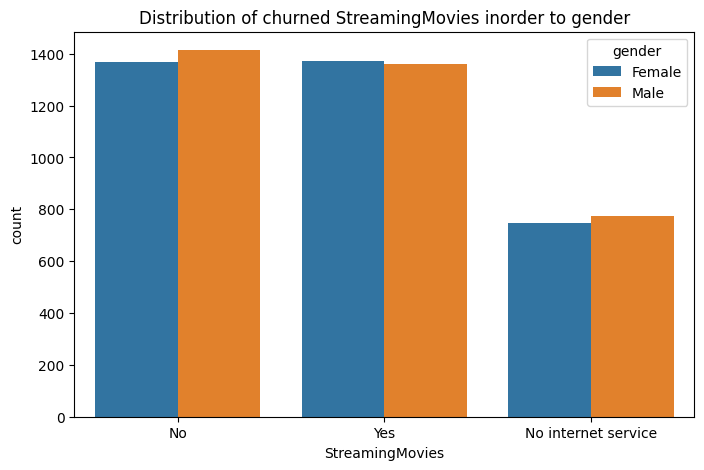

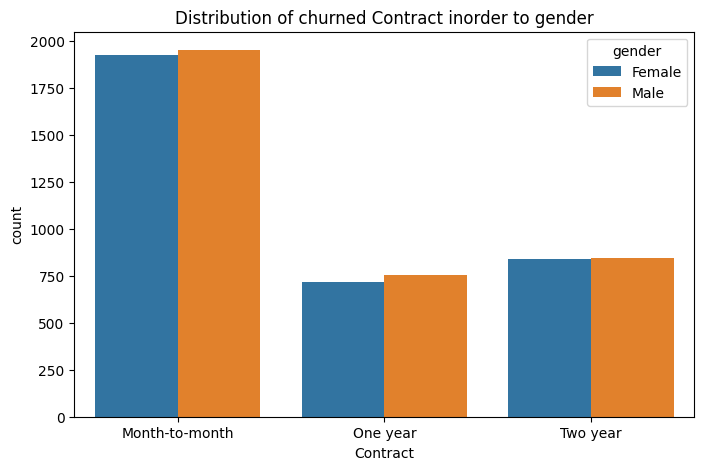

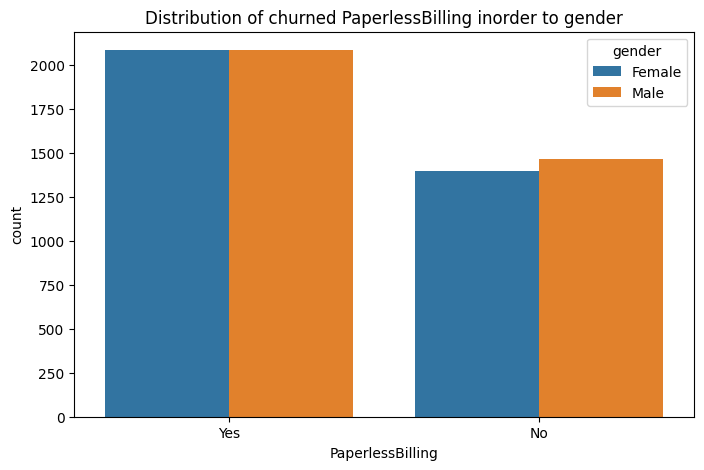

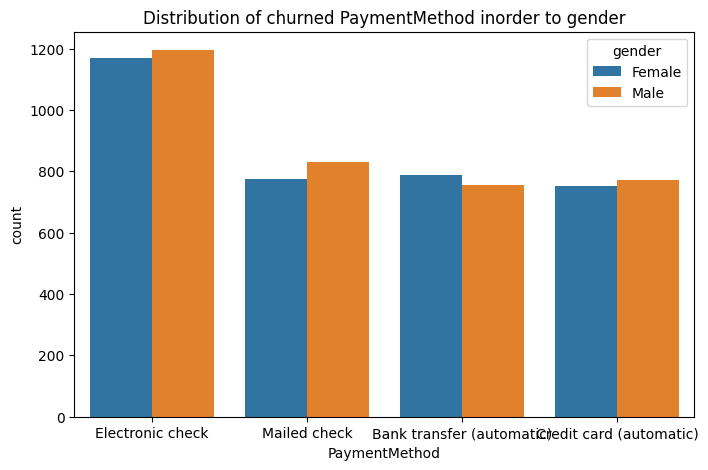

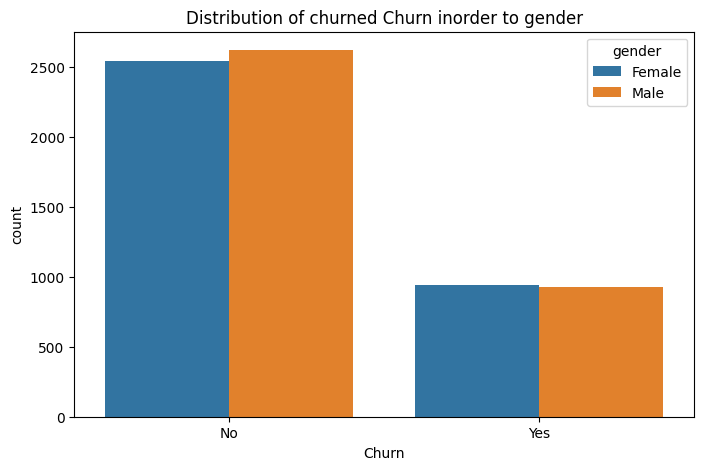

In [25]:
categorical_cols4 = telco_details_new.select_dtypes(include = "object").columns

def uniplot(target_2, predictor, hue = None):
    plt.figure(figsize = (8,5))
    plt.title(f"Distribution of churned {predictor} inorder to gender")
    sns.countplot(data = telco_details_new, x = predictor, hue = "gender")
    plt.show()

for predictor in categorical_cols4:
    uniplot(target_2, predictor, hue = "gender")

## OBSERVATIONS:

- Gender was analyzed to evaluate whether it significantly influenced customer churn behavior across different features. Using contingency tables,groupby analysis and visualizations no strong or consistent relationship was observed between gender and churn. Therefore, gender was not considered a major driving factor for churn prediction, and the analysis was focused more on stronger predictors such as tenure, contract type, monthly charges, and internet service.

In [26]:
telco_details_new.value_counts().sum()

np.int64(7032)

In [27]:
telco_details_new

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


## statistical tests

**Manwhitney U test:**
- monthly charges vs churn
- total charges vs churn

**t-test:**
- tenure vs churn

**Chi2-test:**
- categorical features vs churn

### tenure vs churn

### HYPOTHESIS TESTING - Tenure vs Churn
H0 : mean tenure of churned and non churned customers are equal 

H1 : mean tenure is different

In [28]:
from scipy import stats

In [29]:
churn_yes = telco_details_new[telco_details_new["Churn"] == "Yes"]["tenure"]
churn_no = telco_details_new[telco_details_new["Churn"] == "No"]["tenure"]

In [30]:
t_value, p_value = stats.ttest_ind(churn_yes, churn_no, equal_var= False)

In [31]:
print("t-value:", t_value)
print("p-value:", p_value)

t-value: -34.97187009750348
p-value: 2.3470747188949526e-234


In [32]:
alpha = 0.05 

if p_value < alpha:
    print("reject H0 and accept H1")
if p_value > alpha:
    print("fail to reject H0")

reject H0 and accept H1


### **Insight**

- most customers are in mid tenure but the churn is concentrated at the beginning of the tenure

### HYPOTHESIS TESTING - Monthly Charges vs Churn & Total Charge vs Churn

H0 : both groups have the same distribution of the numerical feature

H1 : both distributions are different 

In [33]:
churn_yes = telco_details_new[telco_details_new["Churn"] == "Yes"]["MonthlyCharges"]
churn_no = telco_details_new[telco_details_new["Churn"] == "No"]["MonthlyCharges"]

In [34]:
numerical_cols = telco_details_new[["MonthlyCharges","TotalCharges"]]

for predictor in numerical_cols:
    stat, p_value = stats.mannwhitneyu(churn_yes, churn_no, alternative = 'two-sided')

    print(predictor, stat, p_value)

    alpha = 0.05 
    
    if p_value < alpha:
        print("reject H0 and accept H1")
    
    if p_value > alpha:
        print("fail to reject H0")

    

MonthlyCharges 5986148.5 8.467195044548749e-54
reject H0 and accept H1
TotalCharges 5986148.5 8.467195044548749e-54
reject H0 and accept H1


### Insight

**Monthly Charges:**
- higher monthly charges are associated with increased likelihood of churn

**Total Charges:**
- this Mann-Whitney U test indicates a statistically significant different in total charges between churn and non churn people. people who churned tend to have less total charges, suggested that they are likely in the early stage of service usage!

## HYPOTHESIS TESTING - categorical features vs churn

H0 : There is no significant association between the categprical feature and customer churn

H1 : both are dependent

In [35]:
from scipy.stats import chi2_contingency

categorical_features = telco_details_new.select_dtypes(include = 'object')
categorical_features = telco_details_new.drop(telco_details_new[["gender","Churn"]], axis = 1)

for predictor in categorical_features:
    contingency_table = pd.crosstab(telco_details_new[predictor],
                               telco_details_new["Churn"])

    chi2_value, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f"feature:{predictor}")
    print(f"p-value:{p_value}")
    
    alpha = 0.05 
    
    if p_value < alpha:
        print("reject H0 and accept H1")
    
    if p_value > alpha:
        print("fail to reject H0")
    
chi2_contingency(contingency_table)

feature:SeniorCitizen
p-value:2.4792557203954705e-36
reject H0 and accept H1
feature:Partner
p-value:3.97379757451591e-36
reject H0 and accept H1
feature:Dependents
p-value:2.0196592017051303e-42
reject H0 and accept H1
feature:tenure
p-value:3.471813048469505e-176
reject H0 and accept H1
feature:PhoneService
p-value:0.34992398942431924
fail to reject H0
feature:MultipleLines
p-value:0.0035679273999811405
reject H0 and accept H1
feature:InternetService
p-value:5.831198962237274e-159
reject H0 and accept H1
feature:OnlineSecurity
p-value:1.4006867477839222e-184
reject H0 and accept H1
feature:OnlineBackup
p-value:7.776099238804965e-131
reject H0 and accept H1
feature:DeviceProtection
p-value:1.9593887862403176e-121
reject H0 and accept H1
feature:TechSupport
p-value:7.407807748843711e-180
reject H0 and accept H1
feature:StreamingTV
p-value:1.324641113169159e-81
reject H0 and accept H1
feature:StreamingMovies
p-value:5.353560421401324e-82
reject H0 and accept H1
feature:Contract
p-value:

Chi2ContingencyResult(statistic=np.float64(6503.575355417988), pvalue=np.float64(0.5858750101997261), dof=6529, expected_freq=array([[0.73421502, 0.26578498],
       [1.46843003, 0.53156997],
       [0.73421502, 0.26578498],
       ...,
       [0.73421502, 0.26578498],
       [0.73421502, 0.26578498],
       [0.73421502, 0.26578498]], shape=(6530, 2)))

## Insights:

- Chi-Square Test (Categorical Features)
The Chi-Square Test of Independence was performed to evaluate whether categorical features have a statistically significant association with customer churn.
Using a significance level of:
α = 0.05
most categorical features produced:
p-value < 0.05
which led to:
Reject H₀ and Accept H₁
This indicates that these features have a significant association with customer churn.

However, for:
Phone Service and total Charges
the p-value was greater than 0.05, leading to:
Fail to Reject H₀
This suggests that Phone Service and Total Charges does not show a strong statistically significant relationship with customer churn and may have weaker predictive influence compared to other categorical features.

## Monthly Charges VS Tenure

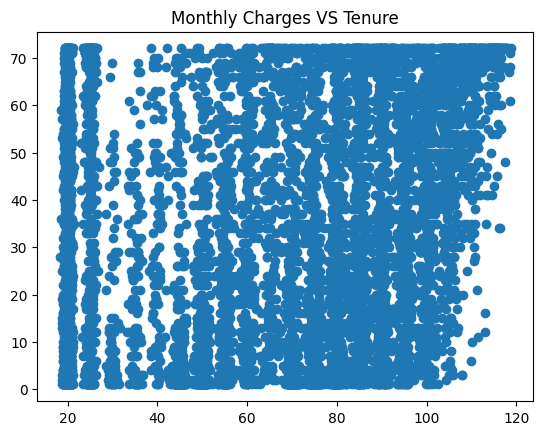

In [36]:
plt.scatter(x = "MonthlyCharges", y = "tenure", data = telco_details_new)
plt.title("Monthly Charges VS Tenure")
plt.show()

In [37]:
telco_details_new[["MonthlyCharges", "tenure"]].corr()

,MonthlyCharges,tenure
MonthlyCharges,1.000000,0.246862
tenure,0.246862,1.000000


### Insight

- monthly charges have less correlation with tenure, suggesting it captures independent information

# before model building

## label encoding for binary features 

## Binary Features

- gender

- partner

- departments

- phone service

- papereless billing

- churn

In [38]:
telco_details_new = telco_details_new.copy()
telco_encoded = telco_details_new.copy()

In [39]:
binary_features = ["SeniorCitizen","gender","Partner","Dependents","PhoneService","PaperlessBilling","Churn"]

for predictor in binary_features:
    telco_encoded[predictor] = telco_encoded[predictor].map({"Yes": 1, "No": 0, "Female": 1, "Male":0})

In [40]:
telco_encoded.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0


## One Hot Encoding for nominal/categorical features

## Categorical Features:

- OnlineSecurity

- OnlineBackup

- DeviceProtection

- TechSupport

- StreamingTV

- StreamingMovies

In [41]:
multi_features = ["MultipleLines", "InternetService","OnlineSecurity", "Contract", "PaymentMethod","OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV","StreamingMovies"]

for predictor in multi_features:
    dummies = pd.get_dummies(telco_encoded[predictor], drop_first= True)
    telco_encoded = pd.concat([telco_encoded, dummies], axis = 1)
    telco_encoded.drop(predictor, axis = 1, inplace = True)

In [42]:
telco_encoded.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,No internet service,Yes,No internet service,Yes,No internet service,Yes,No internet service,Yes,No internet service,Yes
0,1,0,1,0,1,0,1,29.85,29.85,0,...,False,True,False,False,False,False,False,False,False,False
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,True,False,False,False,False,False,False


In [43]:
telco_encoded.isna().sum()

gender                     0
SeniorCitizen              0
Partner                    0
Dependents                 0
tenure                     0
PhoneService               0
PaperlessBilling           0
MonthlyCharges             0
TotalCharges               0
Churn                      0
No phone service           0
Yes                        0
Fiber optic                0
No                         0
No internet service        0
Yes                        0
One year                   0
Two year                   0
Credit card (automatic)    0
Electronic check           0
Mailed check               0
No internet service        0
Yes                        0
No internet service        0
Yes                        0
No internet service        0
Yes                        0
No internet service        0
Yes                        0
No internet service        0
Yes                        0
dtype: int64

In [44]:
telco_details_new.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [45]:
telco_encoded.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'No phone service', 'Yes', 'Fiber optic', 'No',
       'No internet service', 'Yes', 'One year', 'Two year',
       'Credit card (automatic)', 'Electronic check', 'Mailed check',
       'No internet service', 'Yes', 'No internet service', 'Yes',
       'No internet service', 'Yes', 'No internet service', 'Yes',
       'No internet service', 'Yes'],
      dtype='object')

In [46]:
telco_encoded.shape

(7032, 31)

In [47]:
telco_encoded.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,No internet service,Yes,No internet service,Yes,No internet service,Yes,No internet service,Yes,No internet service,Yes
0,1,0,1,0,1,0,1,29.85,29.85,0,...,False,True,False,False,False,False,False,False,False,False
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,True,False,False,False,False,False,False


In [48]:
telco_encoded = telco_encoded.drop("TotalCharges", axis = 1)

In [49]:
telco_encoded.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,No phone service,...,No internet service,Yes,No internet service,Yes,No internet service,Yes,No internet service,Yes,No internet service,Yes
0,1,0,1,0,1,0,1,29.85,0,True,...,False,True,False,False,False,False,False,False,False,False
1,0,0,0,0,34,1,0,56.95,0,False,...,False,False,False,True,False,False,False,False,False,False


In [50]:
import pandas as pd

In [51]:
pd.set_option('display.max_columns', None)

In [52]:
telco_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,No phone service,Yes,Fiber optic,No,No internet service,Yes,One year,Two year,Credit card (automatic),Electronic check,Mailed check,No internet service,Yes,No internet service,Yes,No internet service,Yes,No internet service,Yes,No internet service,Yes
0,1,0,1,0,1,0,1,29.85,0,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False
1,0,0,0,0,34,1,0,56.95,0,False,False,False,False,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False
2,0,0,0,0,2,1,1,53.85,1,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False
3,0,0,0,0,45,0,0,42.30,0,True,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False
4,1,0,0,0,2,1,1,70.70,1,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False


In [53]:
telco_details_new.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **Model Building**

# **Customer Churn Prediction**

# Goal:- predict the churn (Yes/No)



## Dataset + Objective

- Predict Churn (Yes/No)

- Focus: minimize false negatives

In [54]:
X = telco_encoded.drop("Churn", axis = 1)
y = telco_encoded["Churn"]

In [55]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,No phone service,Yes,Fiber optic,No,No internet service,Yes,One year,Two year,Credit card (automatic),Electronic check,Mailed check,No internet service,Yes,No internet service,Yes,No internet service,Yes,No internet service,Yes,No internet service,Yes
0,1,0,1,0,1,0,1,29.85,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False
1,0,0,0,0,34,1,0,56.95,False,False,False,False,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False
2,0,0,0,0,2,1,1,53.85,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False
3,0,0,0,0,45,0,0,42.30,True,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False
4,1,0,0,0,2,1,1,70.70,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False


In [56]:
pd.DataFrame(y.head())

,Churn
0,0
1,0
2,1
3,0
4,1


## Model A

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, train_size = 0.8, random_state=42)

## Import logistic regression

## Model Training

In [59]:
from sklearn.linear_model import LogisticRegression

In [60]:
X_train.dtypes

gender                       int64
SeniorCitizen                int64
Partner                      int64
Dependents                   int64
tenure                       int64
PhoneService                 int64
PaperlessBilling             int64
MonthlyCharges             float64
No phone service              bool
Yes                           bool
Fiber optic                   bool
No                            bool
No internet service           bool
Yes                           bool
One year                      bool
Two year                      bool
Credit card (automatic)       bool
Electronic check              bool
Mailed check                  bool
No internet service           bool
Yes                           bool
No internet service           bool
Yes                           bool
No internet service           bool
Yes                           bool
No internet service           bool
Yes                           bool
No internet service           bool
Yes                 

In [61]:
logistic_model = LogisticRegression(max_iter = 1000)
logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [62]:
logistic_model.coef_

array([[ 0.03105767,  0.26365891,  0.05247926, -0.23675399, -0.03500308,
        -0.1542149 ,  0.27076398, -0.00578203,  0.21087721,  0.30683058,
         1.07709271, -0.1287737 , -0.1287737 , -0.38381945, -0.74622094,
        -1.25549686, -0.13860403,  0.267508  , -0.02077819, -0.1287737 ,
        -0.03155822, -0.1287737 ,  0.05814689, -0.1287737 , -0.34731212,
        -0.1287737 ,  0.36352938, -0.1287737 ,  0.38150067]])

In [63]:
logistic_model.intercept_

array([-0.2685636])

## Model Testing 

In [64]:
y_pred_test = logistic_model.predict(X_test)
y_pred_test

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

## To Evaluate the Model 

- Confusion Matrix

- Classification Report

- Accuracy

- ROC-AUC

### Confusion Matrix - Before Tuning

In [65]:
from sklearn.metrics import confusion_matrix

In [66]:
evaluate = confusion_matrix(y_test , y_pred_test)

In [67]:
evaluate

array([[917, 116],
       [177, 197]])

array( [ [ TruePositive, FalsePositive ]

    [FalseNegative, TrueNegative ] ] )

### Classification Report

In [68]:
from sklearn.metrics import classification_report

In [69]:
evaluate_1 = classification_report(y_test, y_pred_test)

In [70]:
evaluate_1

'              precision    recall  f1-score   support\n\n           0       0.84      0.89      0.86      1033\n           1       0.63      0.53      0.57       374\n\n    accuracy                           0.79      1407\n   macro avg       0.73      0.71      0.72      1407\nweighted avg       0.78      0.79      0.79      1407\n'

### for my data FalseNegative is costly!... so Recall is very important for me. so i choose recall

**Formulea for precision and recall**

- Precision = TP/(TP+FP)

- Recall = TP/(TP+FN)

## F-beta - Formula

F-beta = (1+beta)*(precision*recall / (beta*precision)+recall)

- beta = 1 - Equal precision and recall

- beta = 0.5 - precision focused

- beta = 2 - recall focused



In [71]:
from sklearn.metrics import fbeta_score

In [72]:
fbeta = fbeta_score(y_test, y_pred_test,beta = 2, pos_label=1)  ##fbeta is nothing but f2 score

In [73]:
print(f"Recall:{fbeta}")

Recall:0.5444997236042012


## Observation:

- The baseline Logistic Regression model produced a recall of 54%, indicating that only 54% of actual churned customers were correctly identified. Since reducing false negatives is the primary objective in churn prediction, this performance was considered insufficient, requiring further model optimization.

## Cross Validation

In [74]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, fbeta_score

In [75]:
model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

fbeta = make_scorer(fbeta_score, beta = 2)

scores = cross_val_score(model, X, y, cv = 5, scoring = fbeta)

print(f"Scrores:{scores}")
print(f"Mean:{scores.mean()}")

Scrores:[0.57300275 0.59405941 0.52251251 0.57056229 0.55030573]
Mean:0.5620885372774737


## Testing

In [76]:
y_pred_modA = model.predict(X_test)
y_pred_modA

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

## Evaluate

In [77]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_modA)

array([[917, 116],
       [177, 197]])

In [78]:
from sklearn.metrics import classification_report

classification_report(y_test, y_pred_modA)

'              precision    recall  f1-score   support\n\n           0       0.84      0.89      0.86      1033\n           1       0.63      0.53      0.57       374\n\n    accuracy                           0.79      1407\n   macro avg       0.73      0.71      0.72      1407\nweighted avg       0.78      0.79      0.79      1407\n'

## Observation:

- Cross-validation produced an average recall score of 53%, showing that the model consistently identified only about half of the actual churned customers. Since reducing false negatives is critical in churn prediction, this performance was still considered insufficient, leading to further optimization through hyperparameter tuning and threshold adjustment.

## Regularization - Tune C Parameter

## Hyperparameter Tuning

In [75]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

In [76]:
param_grid = {
    'C' : [0.01, 0.1, 1, 10,50,100],
    'penalty' : ['l1', 'l2'],
    'solver' : ['liblinear'],
    'class_weight' : [None, 'balanced']
}

skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

LogisticRegression(max_iter=1000, class_weight='balanced')

fbeta = make_scorer(fbeta_score, beta = 2)

grid = GridSearchCV(LogisticRegression(max_iter=1000),param_grid, cv = skf,scoring = fbeta)
grid.fit(X_train, y_train)
print(grid.best_params_)
print(f"Scrores:{scores}")

{'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Scrores:[0.57300275 0.59405941 0.52251251 0.57056229 0.55030573]


## Testing

In [77]:
y_pred_modA1 = grid.predict(X_test)
y_pred_modA1

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

## Evaluate

In [78]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_modA1)

array([[738, 295],
       [ 79, 295]])

In [79]:
from sklearn.metrics import classification_report

classification_report(y_test, y_pred_modA1)

'              precision    recall  f1-score   support\n\n           0       0.90      0.71      0.80      1033\n           1       0.50      0.79      0.61       374\n\n    accuracy                           0.73      1407\n   macro avg       0.70      0.75      0.70      1407\nweighted avg       0.80      0.73      0.75      1407\n'

#### **INSIGHT:**

- across all the C values C = 1 give the best score for the all 5 folds (5 different train and test data from one dataset) 

#### Interpretation:

- 5-fold cross validation was performes here using the evaluation metric fbeta. my model reached the average recall of 79%% with consistency across all 5 folds of the cross validation, indicating stable generalization but moderate ability to capture churners. it needs further threshold tuning

## Threshold Tuning

In [80]:
y_prob_test = model.predict_proba(X_test)[:,1]
y_pred_test_new = (y_prob_test > 0.2).astype(int)

In [81]:
y_pred_test_new1 = pd.DataFrame(y_pred_test_new)
y_pred_test_new1

,0
0,0
1,0
2,1
3,0
4,1
...,...
1402,0
1403,1
1404,0
1405,1


## Evaluate

### Confusion Matrix - After Tuning

In [82]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_test_new))

[[661 372]
 [ 60 314]]


In [83]:
from sklearn.metrics import fbeta_score

fbeta = fbeta_score(y_test, y_pred_test_new, beta = 2, pos_label=1)
print(f"fbeta score:{fbeta}")

fbeta score:0.7195233730522457


In [84]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred_test_new)
print(f"Recall:{recall}")

Recall:0.839572192513369


In [85]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test_new))

              precision    recall  f1-score   support

           0       0.92      0.64      0.75      1033
           1       0.46      0.84      0.59       374

    accuracy                           0.69      1407
   macro avg       0.69      0.74      0.67      1407
weighted avg       0.79      0.69      0.71      1407



### After threshold tuning Recall improved from 79% to 84% 

In [51]:
model.n_iter_

array([433], dtype=int32)

## Observation:

- The baseline Logistic Regression model showed moderate precision but low recall, meaning many actual churned customers were being missed. Cross-validation confirmed that the model performance was stable but still insufficient for the business objective.
After hyperparameter tuning, recall improved significantly, although precision decreased slightly. Threshold tuning further improved recall to 84%, which greatly reduced false negatives. Since churn prediction prioritizes recall over precision, this made Logistic Regression much more suitable, though precision became comparatively lower.

## Model B using XGBoost

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, train_size = 0.7, random_state = 42)

In [62]:
from xgboost import XGBClassifier

In [63]:
modelB = XGBClassifier( n_estimators = 200,
                      learning_rate = 0.05,min_child_weight = 3,subsample = 0.8,colsample_bytree = 0.8,gamma = 0.1, reg_alpha = 0.5,
                      reg_lambda = 1.0, random_state = 42, eval_metric = 'logloss')

In [64]:
modelB.fit(X_train.values, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [65]:
type(y_train)

pandas.core.series.Series

In [66]:
type(X_train)

pandas.core.frame.DataFrame

In [71]:
y_pred_test = modelB.predict(X_test.values)

In [72]:
y_pred_test

array([0, 0, 1, ..., 0, 0, 0], shape=(2110,))

In [69]:
y_pred_test = modelB.predict_proba(X_test.values)

In [70]:
y_pred_test

array([[0.9899076 , 0.01009236],
       [0.93913615, 0.06086388],
       [0.23502159, 0.7649784 ],
       ...,
       [0.9950552 , 0.00494478],
       [0.758631  , 0.24136901],
       [0.7584878 , 0.24151216]], shape=(2110, 2), dtype=float32)

## Evaluate the Model B

In [34]:
from sklearn.metrics import confusion_matrix

In [35]:
confusion_matrix(y_test, y_pred_test)

array([[1369,  180],
       [ 271,  290]])

In [36]:
from sklearn.metrics import classification_report

In [37]:
classification_report(y_test, y_pred_test)

'              precision    recall  f1-score   support\n\n           0       0.83      0.88      0.86      1549\n           1       0.62      0.52      0.56       561\n\n    accuracy                           0.79      2110\n   macro avg       0.73      0.70      0.71      2110\nweighted avg       0.78      0.79      0.78      2110\n'

In [38]:
from sklearn.metrics import fbeta_score

In [68]:
fbeta_score(y_test, y_pred_test, beta = 2)

0.5342667649226235

## Cross Validation

In [86]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, fbeta_score

In [87]:
modelB = XGBClassifier( n_estimators = 200,
                      learning_rate = 0.05,min_child_weight = 3,subsample = 0.8,colsample_bytree = 0.8,gamma = 0.1, reg_alpha = 0.5,
                      reg_lambda = 1.0, random_state = 42, eval_metric = 'logloss')
modelB.fit(X_train.values, y_train)

fbeta = make_scorer(fbeta_score, beta = 2)

scores = cross_val_score(modelB, X.values, y, cv = 10, scoring = fbeta)

print(f"Scrores:{scores}")
print(f"Mean:{scores.mean()}")

Scrores:[0.56603774 0.54237288 0.53993251 0.57906459 0.52222222 0.532382
 0.57971014 0.52071669 0.52777778 0.54555681]
Mean:0.5455773347076527


## Testing 

In [88]:
y_pred_modB = modelB.predict(X_test.values)
y_pred_modB

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

## Evaluate

In [89]:
from sklearn.metrics import confusion_matrix

In [90]:
confusion_matrix(y_test, y_pred_modB)

array([[916, 117],
       [176, 198]])

In [91]:
from sklearn.metrics import classification_report

In [92]:
classification_report(y_test, y_pred_modB)

'              precision    recall  f1-score   support\n\n           0       0.84      0.89      0.86      1033\n           1       0.63      0.53      0.57       374\n\n    accuracy                           0.79      1407\n   macro avg       0.73      0.71      0.72      1407\nweighted avg       0.78      0.79      0.79      1407\n'

## Tune Parameters - Hyperparameter Tuning

In [170]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [100,200,300],
    'max_depth' : [3,5,7],
    'learning_rate' : [0.01, 0.05, 0.1],
}

fbeta = make_scorer(fbeta_score, beta = 2)

xgb = XGBClassifier(n_estimators = 200,
              learning_rate = 0.05,min_child_weight = 3,subsample = 0.8,colsample_bytree = 0.8,gamma = 0.1, reg_alpha = 0.5,
              reg_lambda = 1.0, random_state = 42, eval_metric = 'logloss')

grid = GridSearchCV(xgb,param_grid, cv = 5,scoring = fbeta, n_jobs = 1, verbose = 0)
grid.fit(X_train.values, y_train)
print(grid.best_params_)
print(f"Scrores:{scores}")

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Scrores:[0.73913043 0.71216617 0.69346734 0.72283151 0.71641791 0.66666667
 0.72063179 0.685      0.69639279 0.69223108]


'subsample' : [0.7, 0.8, 1.0],
    'colsample_bytree' : [0.7,0.8,1.0],
    'min_child_weight' : [1,3,5],
    'gamma' : [0, 0.1,1],
    'reg_alpha' : [0, 0.1,1],
    'reg_lambda' : [1,5,10]

## Testing 

In [171]:
y_pred_modB1 = grid.predict(X_test.values)

In [172]:
y_pred_modB1

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

## Evaluate

In [173]:
from sklearn.metrics import confusion_matrix

In [174]:
confusion_matrix(y_test, y_pred_modB1)

array([[938,  95],
       [188, 186]])

In [175]:
from sklearn.metrics import classification_report

In [176]:
classification_report(y_test, y_pred_modB1)

'              precision    recall  f1-score   support\n\n           0       0.83      0.91      0.87      1033\n           1       0.66      0.50      0.57       374\n\n    accuracy                           0.80      1407\n   macro avg       0.75      0.70      0.72      1407\nweighted avg       0.79      0.80      0.79      1407\n'

### Observation:

- among all actual churners my model can predict 52% Churners

In [101]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [100,200,300],
    'max_depth' : [3,5,7],
    'learning_rate' : [0.01, 0.05, 0.1],
    'subsample' : [0.7, 0.8, 1.0],
    'colsample_bytree' : [0.7,0.8,1.0] 
}

fbeta = make_scorer(fbeta_score, beta = 2)

xgb = XGBClassifier(n_estimators = 200,
              learning_rate = 0.05,min_child_weight = 3,subsample = 0.8,colsample_bytree = 0.8,gamma = 0.1, reg_alpha = 0.5,
              reg_lambda = 1.0, random_state = 42, eval_metric = 'logloss')

grid = GridSearchCV(xgb,param_grid, cv = 5,scoring = fbeta, n_jobs = 1, verbose = 0)
grid.fit(X_train.values, y_train)
print(grid.best_params_)
print(f"Scrores:{scores}")

{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Scrores:[0.56603774 0.54237288 0.53993251 0.57906459 0.52222222 0.532382
 0.57971014 0.52071669 0.52777778 0.54555681]


## Testing

In [124]:
y_pred_test_modelB = grid.predict(X_test.values)

In [125]:
y_pred_test_modelB

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

## Evaluate

In [126]:
from sklearn.metrics import confusion_matrix

In [127]:
evaluate_modelB = confusion_matrix(y_test, y_pred_test_modelB)

In [128]:
evaluate_modelB

array([[932, 101],
       [183, 191]])

In [129]:
from sklearn.metrics import classification_report

In [130]:
evaluate_modelB_2 = classification_report(y_test, y_pred_test_modelB)

In [131]:
evaluate_modelB_2

'              precision    recall  f1-score   support\n\n           0       0.84      0.90      0.87      1033\n           1       0.65      0.51      0.57       374\n\n    accuracy                           0.80      1407\n   macro avg       0.74      0.71      0.72      1407\nweighted avg       0.79      0.80      0.79      1407\n'

## Threshold Tuning

In [132]:
y_prob_test = grid.predict_proba(X_test.values)[:,1]
y_pred_modB = (y_prob_test > 0.2).astype(int)

In [133]:
y_pred_modB

array([0, 0, 1, ..., 0, 1, 0], shape=(1407,))

### Evaluate

In [134]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_modB)

array([[664, 369],
       [ 52, 322]])

In [135]:
from sklearn.metrics import classification_report

classification_report(y_test, y_pred_modB)

'              precision    recall  f1-score   support\n\n           0       0.93      0.64      0.76      1033\n           1       0.47      0.86      0.60       374\n\n    accuracy                           0.70      1407\n   macro avg       0.70      0.75      0.68      1407\nweighted avg       0.80      0.70      0.72      1407\n'

### Observation: 

- XGBoost initially showed low recall with moderate precision, indicating that the default model was not effectively identifying churned customers. Hyperparameter tuning slightly improved precision but had limited effect on recall.
However, after threshold tuning, recall increased sharply to 86%, making XGBoost highly effective at reducing false negatives. Although precision decreased, the balance between recall and precision remained stronger than Logistic Regression, making XGBoost a strong candidate for final model selection.

## Model C

In [145]:
from sklearn.ensemble import RandomForestClassifier

In [146]:
randomforest = RandomForestClassifier(n_estimators = 200, max_depth=10, min_samples_split= 10, min_samples_leaf=5, class_weight='balanced', random_state=42)

In [147]:
randomforest.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [148]:
y_pred_modelC = randomforest.predict(X_test)
y_pred_modelC

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

In [140]:
y_pred_modelC = randomforest.predict_proba(X_test)

In [141]:
y_pred_modelC

array([[0.99429072, 0.00570928],
       [0.83478486, 0.16521514],
       [0.27322189, 0.72677811],
       ...,
       [0.81582272, 0.18417728],
       [0.60674597, 0.39325403],
       [0.997117  , 0.002883  ]], shape=(1407, 2))

In [142]:
from sklearn.metrics import confusion_matrix

In [149]:
evaluate_C = confusion_matrix(y_test.values, y_pred_modelC)
evaluate_C

array([[772, 261],
       [ 94, 280]])

In [150]:
from sklearn.metrics import classification_report

In [151]:
classification_report(y_test.values, y_pred_modelC)

'              precision    recall  f1-score   support\n\n           0       0.89      0.75      0.81      1033\n           1       0.52      0.75      0.61       374\n\n    accuracy                           0.75      1407\n   macro avg       0.70      0.75      0.71      1407\nweighted avg       0.79      0.75      0.76      1407\n'

## Cross Validation

In [152]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, fbeta_score

randomforest = RandomForestClassifier(n_estimators = 200, max_depth=10, min_samples_split= 10, min_samples_leaf=5, class_weight='balanced', random_state=42)

randomforest.fit(X_train.values, y_train)

fbeta = make_scorer(fbeta_score, beta = 2)

scores = cross_val_score(randomforest, X.values, y, cv = 10, scoring = fbeta)

print(f"Scrores:{scores}")
print(f"Mean:{scores.mean()}")


Scrores:[0.73913043 0.71216617 0.69346734 0.72283151 0.71641791 0.66666667
 0.72063179 0.685      0.69639279 0.69223108]
Mean:0.7044935674211146


## Testing

In [153]:
y_test_modC = randomforest.predict(X_test.values)
y_test_modC

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

## Evaluate

In [154]:
from sklearn.metrics import confusion_matrix

In [155]:
confusion_matrix(y_test, y_test_modC)

array([[772, 261],
       [ 94, 280]])

In [156]:
from sklearn.metrics import classification_report

In [157]:
classification_report(y_test, y_test_modC)

'              precision    recall  f1-score   support\n\n           0       0.89      0.75      0.81      1033\n           1       0.52      0.75      0.61       374\n\n    accuracy                           0.75      1407\n   macro avg       0.70      0.75      0.71      1407\nweighted avg       0.79      0.75      0.76      1407\n'

## Hyperparameter Tuning

In [160]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.model_selection import StratifiedKFold

param_grid = {
    'n_estimators' : [100,200,300],
    'max_depth' : [3,10,15,None],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf' : [1,2,5],
    'max_features' : ['sqrt', 'log2'],
    'class_weight' : [None, 'balanced']
    
}

fbeta = make_scorer(fbeta_score, beta = 2)

skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

randomforest = RandomForestClassifier(n_estimators = 200, max_depth=10, min_samples_split= 10,
                                      min_samples_leaf=5, class_weight='balanced', random_state=42)

grid = GridSearchCV(randomforest,param_grid, cv = skf,scoring = fbeta, n_jobs = 1, verbose = 0)
grid.fit(X_train.values, y_train)
print(grid.best_params_)
print(f"Scrores:{scores}")

{'class_weight': 'balanced', 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100}
Scrores:[0.73913043 0.71216617 0.69346734 0.72283151 0.71641791 0.66666667
 0.72063179 0.685      0.69639279 0.69223108]


### Testing

In [161]:
y_pred_modC = grid.predict(X_test.values)

In [162]:
y_pred_modC

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

### Evaluate

In [163]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_modC)

array([[667, 366],
       [ 56, 318]])

In [164]:
from sklearn.metrics import classification_report

classification_report(y_test, y_pred_modC)

'              precision    recall  f1-score   support\n\n           0       0.92      0.65      0.76      1033\n           1       0.46      0.85      0.60       374\n\n    accuracy                           0.70      1407\n   macro avg       0.69      0.75      0.68      1407\nweighted avg       0.80      0.70      0.72      1407\n'

## Threshold Tuning

In [165]:
y_prob_test = grid.predict_proba(X_test.values)[:,1]
y_pred_test_modC = (y_prob_test > 0.2).astype(int)

In [166]:
y_pred_modC

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

In [167]:
y_prob_test

array([0.08169557, 0.22120978, 0.66883688, ..., 0.41607199, 0.4509471 ,
       0.07241886], shape=(1407,))

In [168]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_test_modC)

array([[178, 855],
       [  5, 369]])

In [169]:
from sklearn.metrics import classification_report

classification_report(y_test, y_pred_test_modC)

'              precision    recall  f1-score   support\n\n           0       0.97      0.17      0.29      1033\n           1       0.30      0.99      0.46       374\n\n    accuracy                           0.39      1407\n   macro avg       0.64      0.58      0.38      1407\nweighted avg       0.79      0.39      0.34      1407\n'

## Observation:

- Random Forest performed strongly even at baseline, showing much higher recall than Logistic Regression and XGBoost. This indicates that tree-based models naturally captured churn behavior more effectively.
After hyperparameter tuning, recall improved further. Threshold tuning increased recall dramatically to 99%, meaning almost all churned customers were identified. However, precision dropped sharply to 30%, indicating a large number of false positives. This means the model may predict too many customers as churners, increasing unnecessary retention efforts and business cost.

## Conclusion:

- Three machine learning models were developed and compared for customer churn prediction: Logistic Regression, XGBoost, and Random Forest.
Since the primary business objective was to minimize false negatives and identify churned customers as accurately as possible, recall was selected as the main evaluation metric, while precision was also considered to control excessive false positives.
Although Random Forest achieved the highest recall of 99%, its precision dropped significantly to 30%, indicating a large number of false positive predictions. This would lead to unnecessary retention costs and reduced business efficiency.
Logistic Regression improved considerably after threshold tuning and achieved 84% recall, but its predictive capability remained lower than the ensemble models.
XGBoost provided the best balance between recall and precision, achieving 86% recall and 47% precision after threshold tuning. It successfully reduced false negatives while maintaining better business practicality than Random Forest.
Therefore, XGBoost was selected as the final model for customer churn prediction, as it offered the most effective balance between predictive performance and business impact.